# 🤖 Complete Supervised Learning Master Reference
### Chapters 3–8 (Géron) + Full Algorithm Library (Gudsky Research Foundation)

This notebook merges Chapters 3 through 8 from *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd Edition) by Aurélien Géron, extended with the complete supervised learning algorithm reference from Gudsky Research Foundation (Research Intake 2026).

Each section is clearly organized and every code cell has been annotated with plain-English comments explaining **what** the code does and **why**.

---

## 📚 Table of Contents

| Topic |
|-------|
| [Classification (MNIST, Binary, Multiclass, Multilabel)](#ch3) |
| [Training Linear Models (Regression, Gradient Descent, Regularization, Logistic Regression)](#ch4) |
| [Support Vector Machines (Linear SVM, Nonlinear SVM, SVM Regression)](#ch5) |
| [Decision Trees (Training, Visualizing, Regression)](#ch6) |
| [Ensemble Learning and Random Forests (Voting, Bagging, Boosting, Stacking)](#ch7) |
| [Dimensionality Reduction (PCA, Kernel PCA, LLE, Manifold Learning)](#ch8) |
| [Extra Classification: Naive Bayes, AdaBoost, LDA, Gradient Boosting](#extra-clf) |
| [Full Regression Suite: Polynomial, Ridge, Lasso, Elastic Net, etc.](#regression-full) |
| [Robust Regression ⭐: Huber, RANSAC, Theil-Sen, Gaussian Process](#robust) |
| [Real-World Projects: Spam Detection, Algorithm Comparison](#projects-ref) |
| [Best Practices & Selection Guide: Do's/Don'ts, When to Use What](#best-practices-ref) |

---

<a id='supervised'></a>

| Section | Algorithms |
|---------|-----------|
| [Extra Classification](#extra-clf) | Naive Bayes, AdaBoost, LDA, Gradient Boosting Classifier |
| [Regression Algorithms](#regression-full) | Linear, Polynomial, Ridge, Lasso, Elastic Net, Decision Tree, Random Forest, Gradient Boosting, SVR, KNN Regressor, Bayesian Ridge |
| [Robust Regression](#robust) | Huber, RANSAC, Theil-Sen, Gaussian Process Regression ⭐ |
| [Real-World Projects](#projects-ref) | Spam Detection, Algorithm Comparison |
| [Best Practices & Selection Guide](#best-practices-ref) | Do's/Don'ts, When to Use What |

---

## ⚙️ Environment Setup (Shared)

Before running any chapter, execute this cell to configure the Python environment, import shared libraries, and set seeds for reproducibility.


In [75]:
# -------------------------------------------------------
# ENVIRONMENT SETUP (run this cell before any other cell)
# -------------------------------------------------------

# Ensure Python 3.5 or newer is being used
import sys
assert sys.version_info >= (3, 5), 'Python 3.5+ required'

# Ensure Scikit-Learn 0.20 or newer is installed
import sklearn
assert sklearn.__version__ >= '0.20', 'Scikit-Learn 0.20+ required'

# Core numerical and OS libraries
import numpy as np
import os

# Fix random seed so results are reproducible across notebook runs
np.random.seed(42)

# Configure Matplotlib for inline figure rendering
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)   # larger axis labels for readability
mpl.rc('xtick', labelsize=12)  # larger x-tick labels
mpl.rc('ytick', labelsize=12)  # larger y-tick labels

# Utility to persist figures to disk
PROJECT_ROOT_DIR = '.'
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, 'images')
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension='png', resolution=300):
    """Save the current matplotlib figure to the images/ folder."""
    path = os.path.join(IMAGES_PATH, fig_id + '.' + fig_extension)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

print('Setup complete!')


Setup complete!


---
<a id='ch3'></a>
# 📗 Classification

**Key concepts covered:**
- Loading and exploring the MNIST handwritten-digit dataset
- Binary classification (detect digit "5" vs all others)
- Performance measures: confusion matrix, precision, recall, F1, ROC / AUC
- Multiclass, multilabel, and multioutput classification


## 1.1 MNIST Dataset

In [76]:
# -------------------------------------------------------
# LOAD MNIST DATASET
# MNIST is 70,000 grayscale 28x28 images of handwritten digits (0–9).
# fetch_openml downloads it automatically; as_frame=False keeps NumPy arrays.
# -------------------------------------------------------
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
print(mnist.keys())  # shows: data, target, feature_names, DESCR, ...


dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [77]:
# Extract features (pixel values) and labels (digit classes 0–9)
X, y = mnist['data'], mnist['target']

# X has shape (70000, 784) — 70k samples, each with 784 pixel features (28*28)
print('X shape:', X.shape)
print('y shape:', y.shape)

# Labels are loaded as strings by default, convert to integers for math ops
y = y.astype(int)


X shape: (70000, 784)
y shape: (70000,)


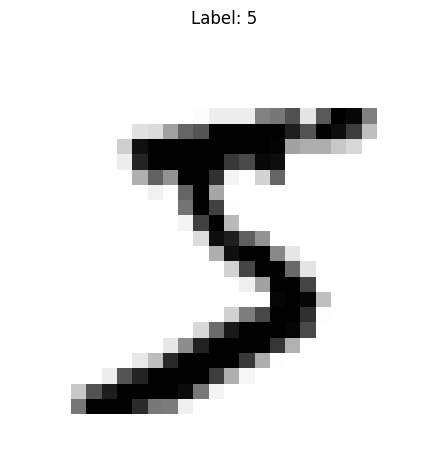

In [78]:
# -------------------------------------------------------
# VISUALISE A SINGLE DIGIT
# Reshape the flat 784-pixel vector back to a 28x28 grid, then display.
# -------------------------------------------------------
some_digit = X[0]                           # grab the first sample
some_digit_image = some_digit.reshape(28, 28)  # unflatten to 2-D image

plt.imshow(some_digit_image, cmap=mpl.cm.binary)  # binary = black & white
plt.axis('off')
plt.title(f'Label: {y[0]}')
save_fig('some_digit_plot')
plt.show()


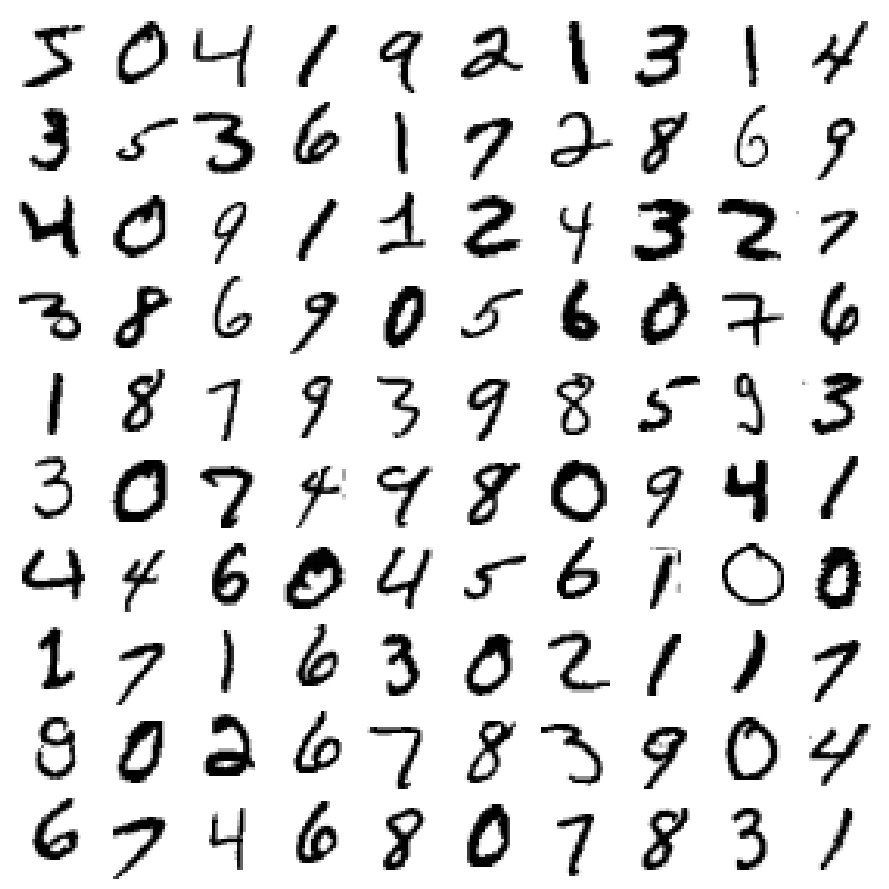

In [79]:
# -------------------------------------------------------
# HELPER: plot a grid of digit images
# -------------------------------------------------------
def plot_digit(data):
    """Display a single 784-D vector as a 28×28 grayscale image."""
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=mpl.cm.binary, interpolation='nearest')
    plt.axis('off')

def plot_digits(instances, images_per_row=10, **options):
    """Tile multiple digit images into a grid for bulk inspection."""
    size = 28
    images_per_row = min(len(instances), images_per_row)
    n_rows = (len(instances) - 1) // images_per_row + 1
    n_empty = n_rows * images_per_row - len(instances)
    # Pad the array with blank images so the grid is rectangular
    padded_instances = np.concatenate(
        [instances, np.zeros((n_empty, size * size))], axis=0)
    image_grid = padded_instances.reshape(
        n_rows, images_per_row, size, size)
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(
        n_rows * size, images_per_row * size)
    plt.imshow(big_image, cmap=mpl.cm.binary, **options)
    plt.axis('off')

# Show first 100 digits as a 10×10 grid
plt.figure(figsize=(9, 9))
plot_digits(X[:100], images_per_row=10)
save_fig('more_digits_plot')
plt.show()


In [80]:
# -------------------------------------------------------
# TRAIN / TEST SPLIT
# MNIST is pre-shuffled; the first 60k are used for training,
# the last 10k for testing — matching the official benchmark split.
# -------------------------------------------------------
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Train size: 60000 | Test size: 10000


## 1.2 Binary Classification — Detecting Digit 5

In [81]:
# -------------------------------------------------------
# BINARY TARGET: Is this digit a 5? (True) or not? (False)
# We reduce the 10-class problem to a simpler True/False question.
# -------------------------------------------------------
y_train_5 = (y_train == 5)  # True for digit-5 images, False for all others
y_test_5  = (y_test  == 5)
print('Positive (digit-5) fraction in training set:',
      y_train_5.mean().round(3))


Positive (digit-5) fraction in training set: 0.09


In [82]:
# -------------------------------------------------------
# STOCHASTIC GRADIENT DESCENT CLASSIFIER (SGDClassifier)
# SGD is fast on large datasets because it updates weights one
# sample at a time. max_iter and tol control convergence.
# -------------------------------------------------------
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_5)  # train on the binary labels

# Predict whether the first digit is a 5
prediction = sgd_clf.predict([some_digit])
print('Predicted is-5:', prediction[0], '| Actual label:', y_train[0])


Predicted is-5: True | Actual label: 5


## 1.3 Performance Measures

In [83]:
# -------------------------------------------------------
# CROSS-VALIDATION ACCURACY
# cross_val_score splits data into 'cv' folds, trains on k-1 folds,
# and tests on the remaining fold — repeated k times.
# This gives a less biased estimate than a single train/test split.
# -------------------------------------------------------
from sklearn.model_selection import cross_val_score

scores = cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')
print('CV Accuracy scores:', scores.round(4))
print('Mean accuracy:', scores.mean().round(4))
# NOTE: High accuracy can be misleading for imbalanced datasets!
#       Only ~10% of images are 5s, so a naive 'never-5' classifier
#       would still achieve ~90% accuracy.


CV Accuracy scores: [0.9504 0.9604 0.9604]
Mean accuracy: 0.957


In [84]:
# -------------------------------------------------------
# CONFUSION MATRIX
# The confusion matrix shows TP, FP, TN, FN counts.
# cross_val_predict returns out-of-fold predictions (unbiased).
# -------------------------------------------------------
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# Generate OOF predictions (each sample is predicted when held out)
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

cm = confusion_matrix(y_train_5, y_train_pred)
print('Confusion Matrix:\n', cm)
# Layout: [[TN, FP],
#           [FN, TP]]


Confusion Matrix:
 [[53892   687]
 [ 1891  3530]]


In [85]:
# -------------------------------------------------------
# PRECISION, RECALL, AND F1 SCORE
# Precision = TP / (TP + FP)  → of predicted positives, how many are correct?
# Recall    = TP / (TP + FN)  → of actual positives, how many did we catch?
# F1        = harmonic mean of precision & recall (penalises extreme imbalance)
# -------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score

prec = precision_score(y_train_5, y_train_pred)
rec  = recall_score(y_train_5, y_train_pred)
f1   = f1_score(y_train_5, y_train_pred)

print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 Score:  {f1:.4f}')


Precision: 0.8371
Recall:    0.6512
F1 Score:  0.7325


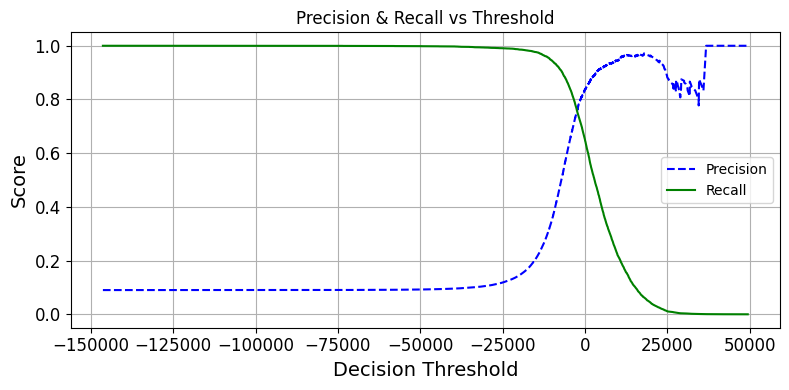

In [86]:
# -------------------------------------------------------
# PRECISION / RECALL TRADE-OFF
# By adjusting the decision threshold we trade precision for recall.
# Lower threshold → more positives predicted → higher recall, lower precision.
# Higher threshold → fewer positives predicted → higher precision, lower recall.
# precision_recall_curve computes these values across all possible thresholds.
# -------------------------------------------------------
from sklearn.metrics import precision_recall_curve

# Get the raw decision scores (not binary predictions)
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method='decision_function')

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Plot precision and recall as a function of the threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1],    'g-',  label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.title('Precision & Recall vs Threshold')
save_fig('precision_recall_vs_threshold_plot')
plt.show()


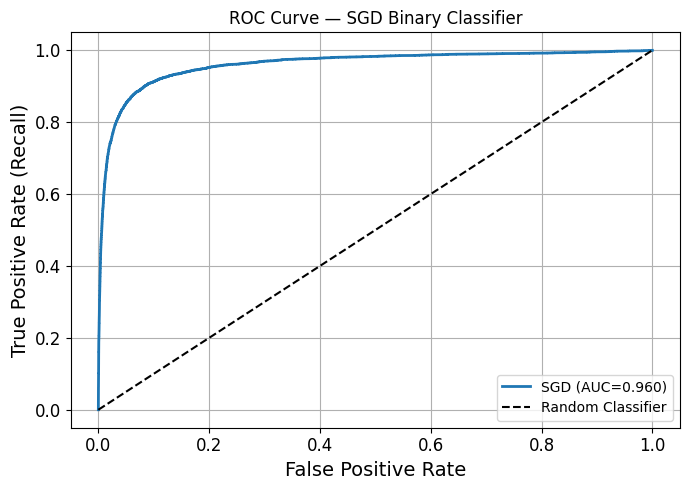

AUC: 0.9605


In [87]:
# -------------------------------------------------------
# ROC CURVE AND AUC
# ROC plots True Positive Rate (recall) vs False Positive Rate.
# AUC = Area Under Curve → 1.0 is perfect, 0.5 is random guessing.
# Use ROC/AUC when classes are balanced; prefer PR curve when imbalanced.
# -------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(y_train_5, y_scores)
auc_score = roc_auc_score(y_train_5, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'SGD (AUC={auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')  # diagonal = random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True)
plt.title('ROC Curve — SGD Binary Classifier')
save_fig('roc_curve_plot')
plt.show()
print('AUC:', round(auc_score, 4))


## 1.4 Multiclass Classification

In [88]:
# -------------------------------------------------------
# MULTICLASS WITH SVM (one-vs-one strategy)
# SVC naturally does binary classification; for k classes it builds
# k*(k-1)/2 binary classifiers and picks the class that wins the most.
# -------------------------------------------------------
from sklearn.svm import SVC

# Train on a small subset for speed (full MNIST takes much longer)
svm_clf = SVC(gamma='auto', random_state=42)
svm_clf.fit(X_train[:1000], y_train[:1000])  # 1000 samples for demonstration

pred = svm_clf.predict([some_digit])
print('SVM prediction:', pred[0], '| True label:', y[0])


SVM prediction: 5 | True label: 5


In [89]:
# -------------------------------------------------------
# ONE-VS-REST (OVR) STRATEGY
# OVR builds k binary classifiers, each deciding 'class i vs all others'.
# It is faster than OVO for large k and works well with LinearSVC/SGD.
# -------------------------------------------------------
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(gamma='auto', random_state=42))
ovr_clf.fit(X_train[:1000], y_train[:1000])

print('OVR prediction:', ovr_clf.predict([some_digit])[0])
print('Number of binary estimators inside OVR:', len(ovr_clf.estimators_))


OVR prediction: 5
Number of binary estimators inside OVR: 10


In [90]:
# -------------------------------------------------------
# SGD MULTICLASS (native support)
# SGDClassifier automatically uses OVR when there are >2 classes,
# so no wrapper is needed.  Scaling the features first improves accuracy.
# -------------------------------------------------------
from sklearn.preprocessing import StandardScaler

# Standardise pixels: subtract mean, divide by std — helps gradient descent
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(float))

sgd_clf.fit(X_train, y_train)  # train on full 10-class labels
print('SGD multiclass prediction:', sgd_clf.predict([some_digit])[0])


SGD multiclass prediction: 3


## 1.5 Error Analysis — Confusion Matrix Heatmap

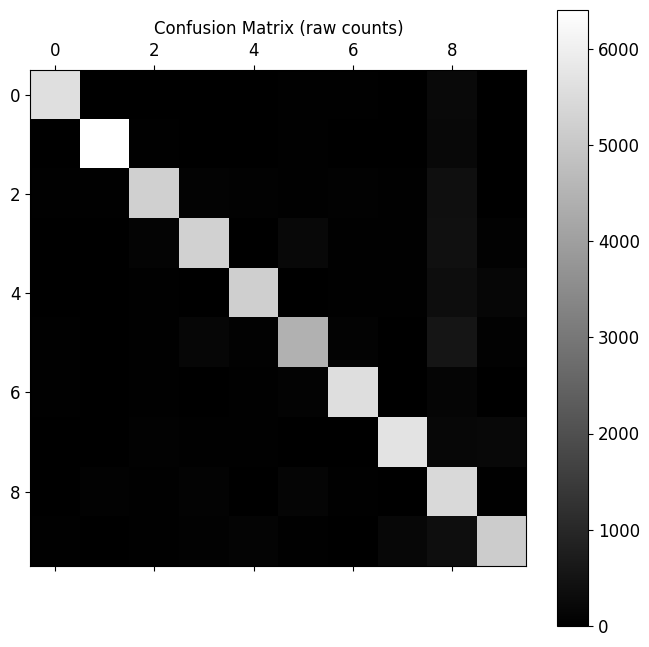

In [91]:
# -------------------------------------------------------
# FULL CONFUSION MATRIX (10 × 10 for digits 0–9)
# Visualising the matrix as a heatmap reveals systematic errors,
# e.g., digits that are commonly confused with each other.
# -------------------------------------------------------
y_train_pred_multi = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred_multi)

# Raw counts — diagonal = correct predictions
fig, ax = plt.subplots(figsize=(8, 8), num=1) # Create or activate figure 1 and its axes
ax.matshow(conf_mx, cmap=plt.cm.gray) # Plot on the created axes
fig.colorbar(ax.images[0], ax=ax) # Add colorbar to the axes, linked to the matshow image
ax.set_title('Confusion Matrix (raw counts)') # Set title on the axes
save_fig('confusion_matrix_plot', tight_layout=False)
plt.show()

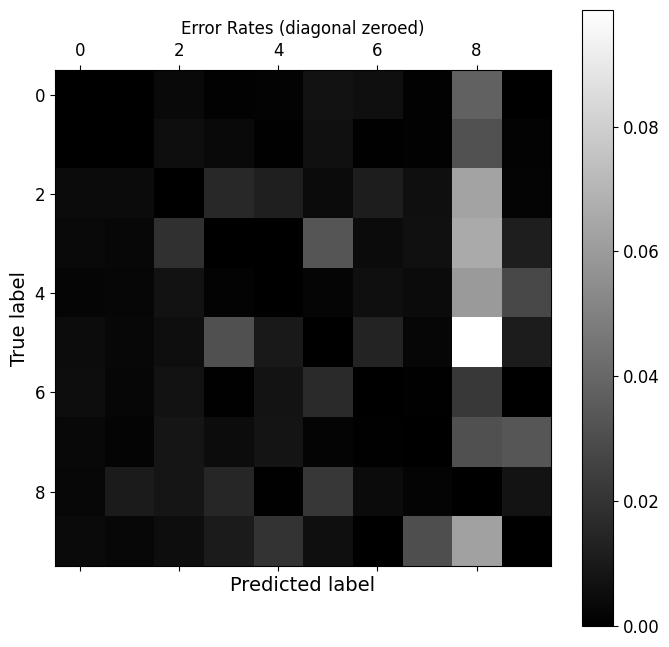

In [92]:
# -------------------------------------------------------
# NORMALISED CONFUSION MATRIX
# Divide each row by the total samples in that class → error rates.
# Then zero-out the diagonal so the remaining off-diagonal errors
# are more visible — bright spots highlight the worst confusions.
# -------------------------------------------------------
row_sums = conf_mx.sum(axis=1, keepdims=True)  # total per true class
norm_conf_mx = conf_mx / row_sums               # normalise by class size

np.fill_diagonal(norm_conf_mx, 0)  # hide correct predictions

fig, ax = plt.subplots(figsize=(8, 8), num=1)
ax.matshow(norm_conf_mx, cmap=plt.cm.gray)
fig.colorbar(ax.images[0], ax=ax)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Error Rates (diagonal zeroed)')
save_fig('confusion_matrix_errors_plot', tight_layout=False)
plt.show()

## 1.6 Multilabel and Multioutput Classification

In [93]:
# -------------------------------------------------------
# MULTILABEL CLASSIFICATION
# Each sample can belong to MULTIPLE classes simultaneously.
# Here each digit image gets two labels:
#   - is_large : True if digit >= 7
#   - is_odd   : True if digit is odd
# KNeighborsClassifier natively supports multilabel output.
# -------------------------------------------------------
from sklearn.neighbors import KNeighborsClassifier

# Build a 2-column target array (one column per label)
y_train_large = (y_train >= 7)          # large digit?
y_train_odd   = (y_train % 2 == 1)      # odd digit?
y_multilabel  = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

# Predict both labels for the sample digit
pred_multi = knn_clf.predict([some_digit])
print('Multilabel prediction [is_large, is_odd]:', pred_multi)
print('True digit:', y[0], '| Should be large (>=7)?', y[0]>=7, '| Odd?', y[0]%2==1)


Multilabel prediction [is_large, is_odd]: [[False  True]]
True digit: 5 | Should be large (>=7)? False | Odd? True


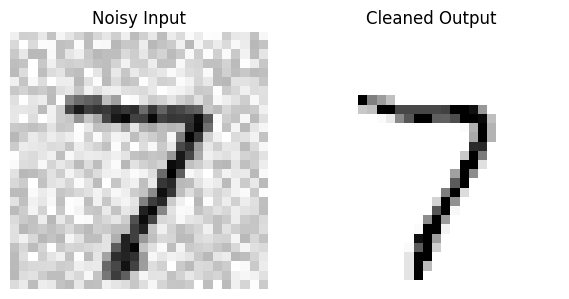

In [94]:
# -------------------------------------------------------
# MULTIOUTPUT CLASSIFICATION (noise removal example)
# Each output is a continuous value (clean pixel), not just a class label.
# Task: given a noisy MNIST image, predict the clean pixel values.
# -------------------------------------------------------
# Add uniform random noise (0–100) to each pixel
noise_train = np.random.randint(0, 100, (len(X_train), 784))
noise_test  = np.random.randint(0, 100, (len(X_test),  784))
X_train_mod = X_train + noise_train   # noisy inputs
X_test_mod  = X_test  + noise_test

# Targets = the ORIGINAL (clean) pixel values
y_train_mod = X_train
y_test_mod  = X_test

# Train KNN to predict all 784 pixel values simultaneously
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])

# Compare noisy input vs cleaned output
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_test_mod[0].reshape(28, 28), cmap='binary')
axes[0].set_title('Noisy Input')
axes[0].axis('off')
axes[1].imshow(clean_digit.reshape(28, 28), cmap='binary')
axes[1].set_title('Cleaned Output')
axes[1].axis('off')
save_fig('noisy_digit_example_plot')
plt.show()


---
<a id='ch4'></a>
# 📘 Training Linear Models

**Key concepts covered:**
- Linear Regression: Normal Equation & pseudoinverse
- Gradient Descent: Batch, Stochastic (SGD), Mini-batch
- Polynomial Regression and learning curves
- Regularisation: Ridge (L2), Lasso (L1), Elastic Net, Early Stopping
- Logistic Regression & Softmax Regression


## 2.1 Linear Regression — Normal Equation

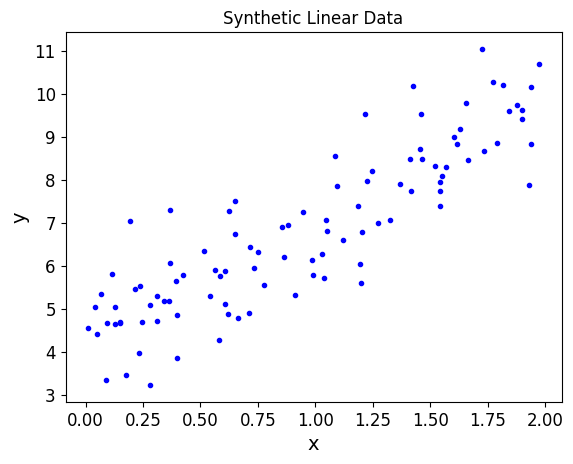

In [95]:
# -------------------------------------------------------
# GENERATE SYNTHETIC LINEAR DATA
# y = 4 + 3*x + Gaussian noise
# We'll use this simple dataset to demonstrate regression.
# -------------------------------------------------------
np.random.seed(42)
X_lin = 2 * np.random.rand(100, 1)                    # 100 points in [0, 2]
y_lin = 4 + 3 * X_lin + np.random.randn(100, 1)       # true slope=3, intercept=4

plt.plot(X_lin, y_lin, 'b.')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Synthetic Linear Data')
plt.show()


Estimated intercept (theta_0): 4.2151
Estimated slope     (theta_1): 2.7701


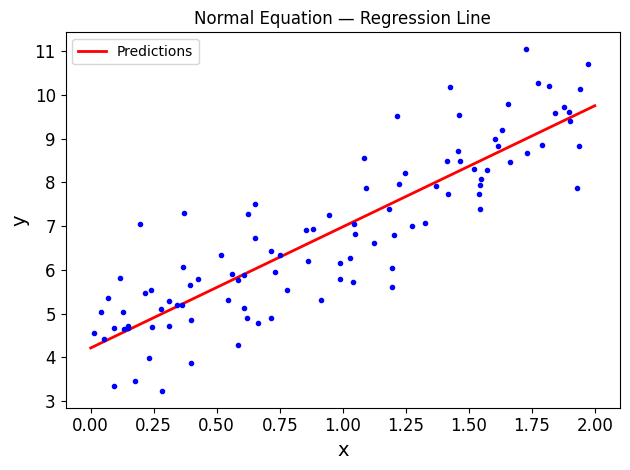

In [96]:
# -------------------------------------------------------
# NORMAL EQUATION: theta = (X^T X)^{-1} X^T y
# Closed-form solution that finds the exact least-squares optimum.
# Works well for small datasets; slow (O(n^3)) for large feature sets.
# -------------------------------------------------------
X_b = np.c_[np.ones((100, 1)), X_lin]   # prepend bias column (x0 = 1)
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_lin)

print('Estimated intercept (theta_0):', theta_best[0][0].round(4))
print('Estimated slope     (theta_1):', theta_best[1][0].round(4))
# Should be close to [4, 3] — the true parameters

# Predict on two new points to draw the regression line
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)

plt.plot(X_new, y_predict, 'r-', linewidth=2, label='Predictions')
plt.plot(X_lin, y_lin, 'b.')
plt.legend(); plt.xlabel('x'); plt.ylabel('y')
plt.title('Normal Equation — Regression Line')
save_fig('linear_model_predictions_plot')
plt.show()


In [97]:
# -------------------------------------------------------
# SCIKIT-LEARN LINEAR REGRESSION
# Uses the pseudoinverse (SVD-based) internally — more numerically
# stable than inverting X^T X directly.
# -------------------------------------------------------
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_lin, y_lin)

print('Sklearn intercept:', lin_reg.intercept_[0].round(4))
print('Sklearn coef:     ', lin_reg.coef_[0][0].round(4))
print('Predictions at x=0 and x=2:', lin_reg.predict(X_new).flatten().round(4))


Sklearn intercept: 4.2151
Sklearn coef:      2.7701
Predictions at x=0 and x=2: [4.2151 9.7553]


## 2.2 Gradient Descent

In [98]:
# -------------------------------------------------------
# BATCH GRADIENT DESCENT (BGD)
# Updates theta using the gradient computed over the ENTIRE dataset.
# Guaranteed to converge to the global minimum for convex MSE loss.
# eta (learning rate) controls step size:
#   too small → slow convergence; too large → diverges.
# -------------------------------------------------------
eta = 0.1          # learning rate
n_iterations = 1000
m = 100            # number of training samples

theta = np.random.randn(2, 1)   # random starting point

for iteration in range(n_iterations):
    # Compute gradient of MSE = (2/m) * X^T (X*theta - y)
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y_lin)
    # Step in the opposite direction of the gradient
    theta = theta - eta * gradients

print('BGD result — theta:', theta.flatten().round(4))


BGD result — theta: [4.2151 2.7701]


In [99]:
# -------------------------------------------------------
# STOCHASTIC GRADIENT DESCENT (SGD)
# Updates theta using ONE random sample per step.
# Much faster per iteration but noisy — uses a learning schedule
# (simulated annealing) to reduce the learning rate over time.
# -------------------------------------------------------
n_epochs = 50
t0, t1 = 5, 50     # learning schedule parameters

def learning_schedule(t):
    """Decrease learning rate over time: eta = t0 / (t + t1)"""
    return t0 / (t + t1)

theta = np.random.randn(2, 1)   # random init

for epoch in range(n_epochs):
    for i in range(m):
        # Pick one random training sample
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y_lin[random_index:random_index+1]
        # Gradient for a single sample
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)  # decreasing LR
        theta = theta - eta * gradients

print('SGD result — theta:', theta.flatten().round(4))


SGD result — theta: [4.1848 2.7304]


In [100]:
# -------------------------------------------------------
# SKLEARN SGDRegressor
# Equivalent to the manual SGD loop above, but optimised and
# with many additional features (regularisation, early stopping, etc.)
# -------------------------------------------------------
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None,
                       eta0=0.1, random_state=42)
sgd_reg.fit(X_lin, y_lin.ravel())  # ravel() flattens (100,1) → (100,)

print('SGDRegressor intercept:', sgd_reg.intercept_.round(4))
print('SGDRegressor coef:     ', sgd_reg.coef_.round(4))


SGDRegressor intercept: [4.2437]
SGDRegressor coef:      [2.8251]


## 2.3 Polynomial Regression & Learning Curves

In [101]:
# -------------------------------------------------------
# POLYNOMIAL REGRESSION
# Linear models can fit curves by adding polynomial features.
# PolynomialFeatures(degree=2) adds x^2 alongside x, then
# a LinearRegression is fitted on these expanded features.
# -------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)
m = 100
X_poly_data = 6 * np.random.rand(m, 1) - 3       # x ∈ [-3, 3]
y_poly_data = 0.5 * X_poly_data**2 + X_poly_data + 2 + np.random.randn(m, 1)

# Add a squared feature: [x] → [x, x²]
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X_poly_data)
print('Original shape:', X_poly_data.shape, '→ Extended shape:', X_poly.shape)

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y_poly_data)
print('Fitted coefficients (bias, x, x²):', lin_reg.intercept_.round(3), lin_reg.coef_.round(3))


Original shape: (100, 1) → Extended shape: (100, 2)
Fitted coefficients (bias, x, x²): [1.781] [[0.934 0.565]]


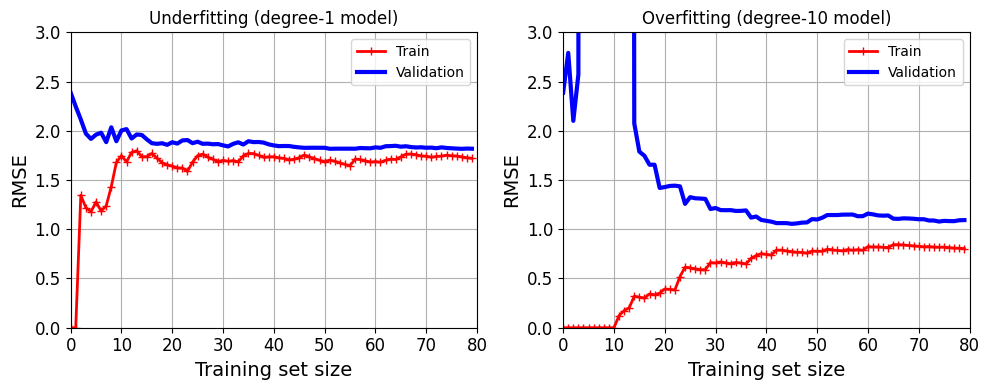

In [102]:
# -------------------------------------------------------
# LEARNING CURVES — diagnose underfitting vs overfitting
# Plot train error and validation error as training set size grows.
# - Underfitting: both errors are high and close together
# - Overfitting : train error is low, validation error is much higher
# -------------------------------------------------------
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

def plot_learning_curves(model, X, y):
    """Train model on incrementally larger subsets and plot train/val RMSE."""
    X_train_lc, X_val_lc, y_train_lc, y_val_lc = train_test_split(
        X, y, test_size=0.2, random_state=10)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train_lc) + 1):
        model.fit(X_train_lc[:m], y_train_lc[:m])
        y_train_pred = model.predict(X_train_lc[:m])
        y_val_pred   = model.predict(X_val_lc)
        train_errors.append(mean_squared_error(y_train_lc[:m], y_train_pred))
        val_errors.append(  mean_squared_error(y_val_lc,       y_val_pred))
    plt.plot(np.sqrt(train_errors), 'r-+', linewidth=2, label='Train')
    plt.plot(np.sqrt(val_errors),   'b-',  linewidth=3, label='Validation')
    plt.xlabel('Training set size'); plt.ylabel('RMSE'); plt.legend(); plt.grid(True)

# Underfitting example: plain linear model on quadratic data
lin_reg_lc = LinearRegression()
plt.figure(figsize=(10, 4))
plt.subplot(121)
plot_learning_curves(lin_reg_lc, X_poly_data, y_poly_data)
plt.title('Underfitting (degree-1 model)')
plt.axis([0, 80, 0, 3])

# Overfitting example: degree-10 polynomial
poly_reg_lc = Pipeline([
    ('poly_features', PolynomialFeatures(degree=10, include_bias=False)),
    ('lin_reg', LinearRegression()),
])
plt.subplot(122)
plot_learning_curves(poly_reg_lc, X_poly_data, y_poly_data)
plt.title('Overfitting (degree-10 model)')
plt.axis([0, 80, 0, 3])

save_fig('learning_curves_plot')
plt.tight_layout(); plt.show()


## 2.4 Regularised Linear Models

In [103]:
# -------------------------------------------------------
# RIDGE REGRESSION (L2 regularisation)
# Adds a penalty term = alpha * sum(theta^2) to the loss.
# Forces weights toward zero, reducing overfitting.
# Higher alpha → stronger regularisation → simpler model.
# -------------------------------------------------------
from sklearn.linear_model import Ridge

np.random.seed(42)
m = 20
X_reg = 3 * np.random.rand(m, 1)
y_reg = 1 + 0.5 * X_reg + np.random.randn(m, 1) / 1.5
X_new_reg = np.linspace(0, 3, 100).reshape(100, 1)

# Cholesky solver is exact and fast for moderate-sized datasets
ridge_reg = Ridge(alpha=1, solver='cholesky', random_state=42)
ridge_reg.fit(X_reg, y_reg)
print('Ridge prediction at x=1.5:', ridge_reg.predict([[1.5]]).round(4))


Ridge prediction at x=1.5: [1.5507]


In [104]:
# -------------------------------------------------------
# LASSO REGRESSION (L1 regularisation)
# Adds penalty = alpha * sum(|theta|).
# Key difference from Ridge: Lasso tends to set some weights to EXACTLY zero,
# performing automatic feature selection.
# -------------------------------------------------------
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_reg, y_reg)
print('Lasso prediction at x=1.5:', lasso_reg.predict([[1.5]]).round(4))


Lasso prediction at x=1.5: [1.5379]


In [105]:
# -------------------------------------------------------
# ELASTIC NET (combines L1 + L2)
# ElasticNet mixes Ridge (l1_ratio=0) and Lasso (l1_ratio=1).
# Useful when there are many correlated features:
# Lasso might pick one arbitrarily; Elastic Net selects groups.
# -------------------------------------------------------
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X_reg, y_reg)
print('ElasticNet prediction at x=1.5:', elastic_net.predict([[1.5]]).round(4))


ElasticNet prediction at x=1.5: [1.5433]


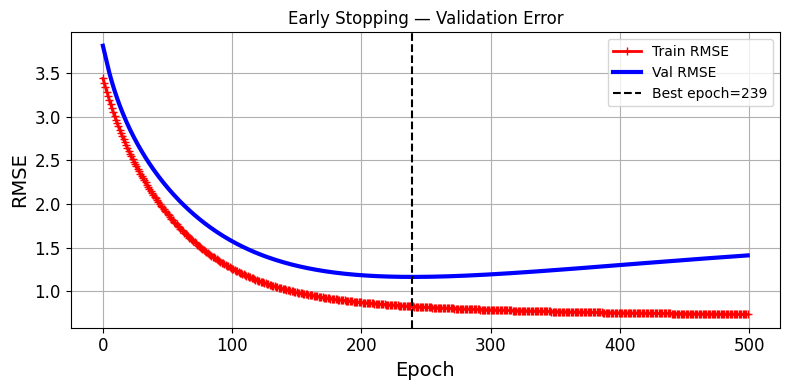

Best epoch: 239  |  Best val RMSE: 1.1625


In [106]:
# -------------------------------------------------------
# EARLY STOPPING
# Stop training as soon as validation error starts rising.
# This is a form of regularisation — prevents the model from
# overfitting as it trains for more epochs.
# -------------------------------------------------------
from copy import deepcopy
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
m = 100
X_es = 6 * np.random.rand(m, 1) - 3
y_es = 2 + X_es + 0.5 * X_es**2 + np.random.randn(m, 1)

X_train_es, X_val_es, y_train_es, y_val_es = train_test_split(
    X_es[:50], y_es[:50].ravel(), test_size=0.5, random_state=10)

# Create polynomial + scaling pipeline (degree 90 → strong overfit potential)
poly_scaler = Pipeline([
    ('poly_features', PolynomialFeatures(degree=90, include_bias=False)),
    ('std_scaler', StandardScaler())
])
X_train_poly = poly_scaler.fit_transform(X_train_es)
X_val_poly   = poly_scaler.transform(X_val_es)

# Train one epoch at a time and track validation error
sgd_es = SGDRegressor(max_iter=1, tol=None, warm_start=True, # Changed tol from -np.inf to None
                      penalty=None, learning_rate='constant', eta0=0.0005,
                      random_state=42)

n_epochs = 500
best_val_error = float('inf')
best_model = None
train_errors_es, val_errors_es = [], []

for epoch in range(n_epochs):
    sgd_es.fit(X_train_poly, y_train_es)
    y_val_pred = sgd_es.predict(X_val_poly)
    val_error  = mean_squared_error(y_val_es, y_val_pred)
    val_errors_es.append(val_error)
    train_errors_es.append(mean_squared_error(y_train_es, sgd_es.predict(X_train_poly)))
    # Save best model checkpoint
    if val_error < best_val_error:
        best_val_error = val_error
        best_model = deepcopy(sgd_es)
        best_epoch = epoch

plt.figure(figsize=(8, 4))
plt.plot(np.sqrt(train_errors_es), 'r-+', linewidth=2, label='Train RMSE')
plt.plot(np.sqrt(val_errors_es),   'b-',  linewidth=3, label='Val RMSE')
plt.axvline(best_epoch, color='k', linestyle='--', label=f'Best epoch={best_epoch}')
plt.xlabel('Epoch'); plt.ylabel('RMSE'); plt.legend(); plt.grid(True)
plt.title('Early Stopping — Validation Error')
save_fig('early_stopping_plot')
plt.show()
print(f'Best epoch: {best_epoch}  |  Best val RMSE: {np.sqrt(best_val_error):.4f}')

## 2.5 Logistic Regression

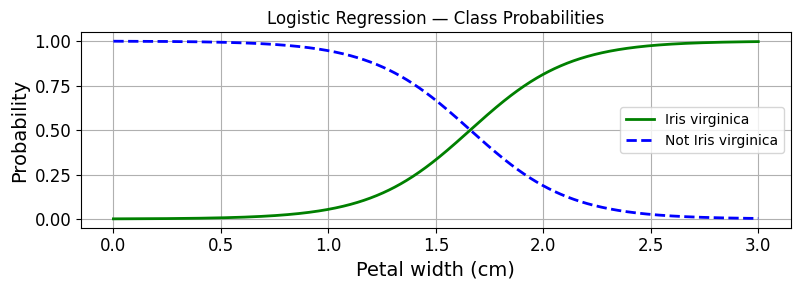

In [107]:
# -------------------------------------------------------
# LOGISTIC REGRESSION — IRIS DATASET
# LogisticRegression models P(y=1|x) using the sigmoid function.
# Output is a probability; a threshold (default 0.5) converts to class label.
# -------------------------------------------------------
from sklearn import datasets
from sklearn.linear_model import LogisticRegression

iris = datasets.load_iris()
# Binary task: is this Iris virginica (class 2) or not?
X_iris = iris['data'][:, 3:]          # petal width only
y_iris = (iris['target'] == 2).astype(int)

log_reg = LogisticRegression(solver='lbfgs', random_state=42)
log_reg.fit(X_iris, y_iris)

# Plot predicted probabilities across the petal-width range
X_new_iris = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new_iris)

plt.figure(figsize=(8, 3))
plt.plot(X_new_iris, y_proba[:, 1], 'g-', linewidth=2, label='Iris virginica')
plt.plot(X_new_iris, y_proba[:, 0], 'b--', linewidth=2, label='Not Iris virginica')
plt.xlabel('Petal width (cm)'); plt.ylabel('Probability')
plt.legend(); plt.grid(True)
plt.title('Logistic Regression — Class Probabilities')
save_fig('logistic_regression_plot')
plt.show()


In [108]:
# -------------------------------------------------------
# SOFTMAX REGRESSION (Multinomial Logistic Regression)
# Generalises binary logistic regression to k > 2 classes.
# Uses the softmax function: P(class k | x) = exp(score_k) / sum(exp(scores))
# multi_class='multinomial' activates the true Softmax loss.
# -------------------------------------------------------
X_soft = iris['data'][:, (2, 3)]   # petal length and width
y_soft = iris['target']            # 3 classes: 0, 1, 2

softmax_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                                  C=10, random_state=42)
softmax_reg.fit(X_soft, y_soft)

# Predict class and probabilities for a sample [petal_len=5, petal_wid=2]
print('Predicted class:', softmax_reg.predict([[5, 2]]))
print('Class probs    :', softmax_reg.predict_proba([[5, 2]]).round(4))


Predicted class: [2]
Class probs    : [[0.     0.0574 0.9426]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


---
<a id='ch5'></a>
# 📙 Support Vector Machines (SVMs)

**Key concepts covered:**
- Hard-margin and soft-margin linear SVM classification
- Nonlinear SVM with polynomial and RBF kernels
- The kernel trick (implicit high-dimensional feature mapping)
- SVM Regression (SVR)


## 3.1 Linear SVM Classification

In [109]:
# -------------------------------------------------------
# LINEAR SVM — HARD MARGIN
# SVM finds the widest possible 'street' (margin) between classes.
# The decision boundary is equidistant from the closest points (support vectors).
# LinearSVC is faster than SVC(kernel='linear') for large datasets.
# C controls the margin width: small C → wider margin (more violations allowed)
# -------------------------------------------------------
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Iris: binary task — detect Iris setosa (class 0)
iris = datasets.load_iris()
X_svm = iris['data'][:, (2, 3)]    # petal length, petal width
y_svm = (iris['target'] == 0).astype(int)  # 1 = setosa

# Pipeline: scale features first (SVM is sensitive to feature scale)
svm_clf_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42)),
])
svm_clf_linear.fit(X_svm, y_svm)

# Predict for a sample
sample = [[5.5, 1.7]]
print('LinearSVC prediction:', svm_clf_linear.predict(sample))


LinearSVC prediction: [0]


## 3.2 Nonlinear SVM — Polynomial Kernel

In [110]:
# -------------------------------------------------------
# POLYNOMIAL KERNEL SVM
# The kernel trick implicitly maps features to a higher-dimensional space
# without computing the transformation explicitly (avoids the curse of
# dimensionality).
# degree: polynomial degree; coef0: influence of high-degree vs low-degree terms
# C: regularisation (lower C → larger margin, more misclassifications allowed)
# -------------------------------------------------------
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# make_moons: a classic nonlinearly-separable 2-class dataset
X_moons, y_moons = make_moons(n_samples=100, noise=0.15, random_state=42)

poly_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='poly', degree=3, coef0=1, C=5)),
])
poly_kernel_svm_clf.fit(X_moons, y_moons)
print('Polynomial SVM trained on moons dataset.')


Polynomial SVM trained on moons dataset.


## 3.3 Nonlinear SVM — RBF (Gaussian) Kernel

RBF SVM trained (gamma=5, C=0.001).


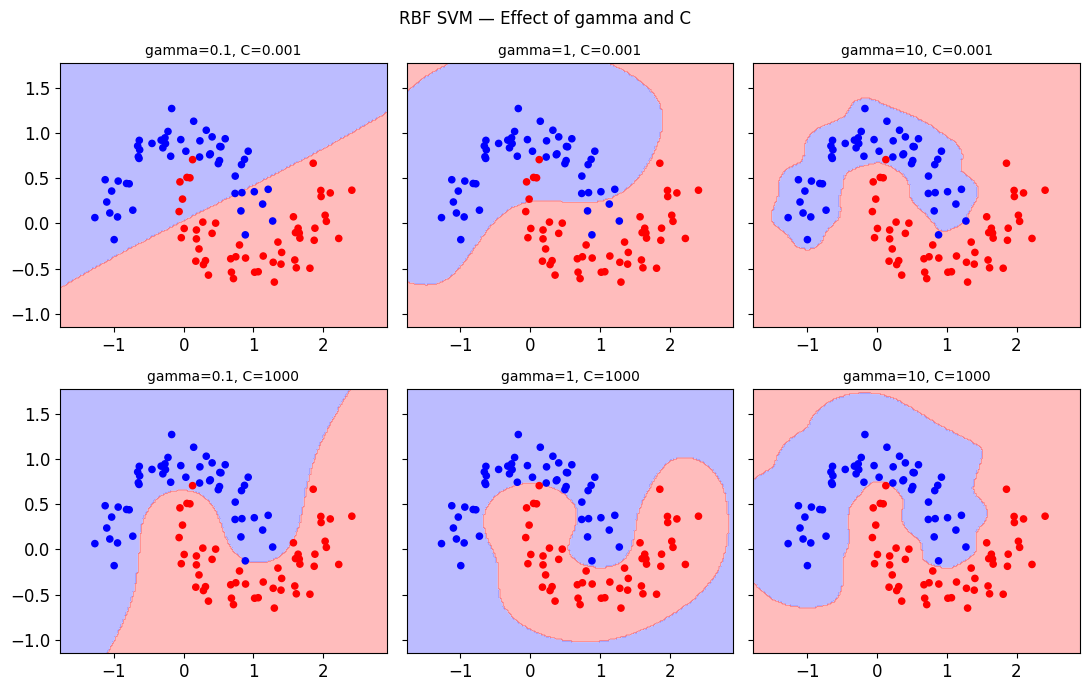

In [111]:
# -------------------------------------------------------
# RBF KERNEL SVM (most commonly used kernel)
# RBF = Radial Basis Function = Gaussian kernel.
# gamma controls the shape of the Gaussian:
#   high gamma → narrow bell → complex boundary (risk of overfitting)
#   low  gamma → wide bell  → smoother boundary (risk of underfitting)
# C controls the trade-off between margin width and misclassifications.
# -------------------------------------------------------
rbf_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='rbf', gamma=5, C=0.001)),
])
rbf_kernel_svm_clf.fit(X_moons, y_moons)
print('RBF SVM trained (gamma=5, C=0.001).')

# Compare multiple gamma/C combinations
fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharey=True)
for idx, gamma in enumerate([0.1, 1, 10]):
    for jdx, C in enumerate([0.001, 1000]):
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('svm',    SVC(kernel='rbf', gamma=gamma, C=C)),
        ])
        clf.fit(X_moons, y_moons)
        ax = axes[jdx, idx]
        # Decision boundary visualisation
        xx, yy = np.meshgrid(
            np.linspace(X_moons[:, 0].min()-0.5, X_moons[:, 0].max()+0.5, 200),
            np.linspace(X_moons[:, 1].min()-0.5, X_moons[:, 1].max()+0.5, 200))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
        ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, s=20, cmap='bwr')
        ax.set_title(f'gamma={gamma}, C={C}', fontsize=10)
plt.suptitle('RBF SVM — Effect of gamma and C')
save_fig('rbf_svm_comparison_plot')
plt.tight_layout(); plt.show()


## 3.4 SVM Regression (SVR)

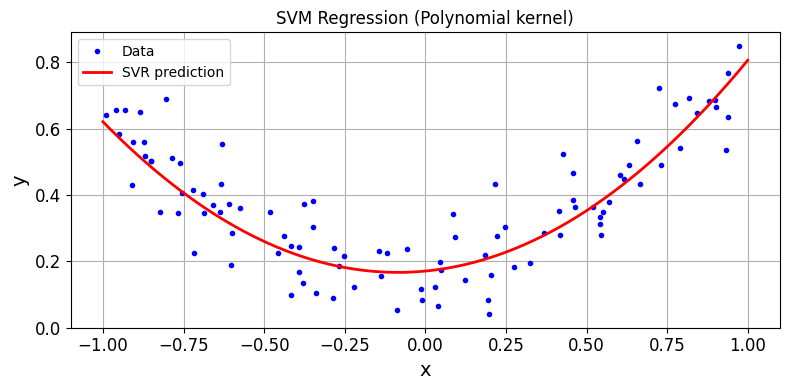

In [112]:
# -------------------------------------------------------
# SUPPORT VECTOR REGRESSION (SVR)
# Instead of maximising the margin between classes, SVR tries to
# FIT as many points as possible within a tube of width epsilon.
# Points inside the tube do not contribute to the loss (epsilon-insensitive loss).
# C controls the trade-off: large C → smaller tube (more overfitting).
# -------------------------------------------------------
from sklearn.svm import SVR

# Create synthetic nonlinear regression data
np.random.seed(42)
m_svr = 100
X_svr = 2 * np.random.rand(m_svr, 1) - 1
y_svr = (0.2 + 0.1 * X_svr + 0.5 * X_svr**2
         + np.random.randn(m_svr, 1) / 10).ravel()

# Fit SVR with RBF kernel; epsilon is the tube half-width
svr_poly = SVR(kernel='poly', degree=2, C=100, epsilon=0.1, coef0=1)
svr_poly.fit(X_svr, y_svr)

X_plot = np.linspace(-1, 1, 300).reshape(-1, 1)
y_plot = svr_poly.predict(X_plot)

plt.figure(figsize=(8, 4))
plt.plot(X_svr, y_svr, 'b.', label='Data')
plt.plot(X_plot, y_plot, 'r-', linewidth=2, label='SVR prediction')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(True)
plt.title('SVM Regression (Polynomial kernel)')
save_fig('svm_regression_plot')
plt.show()


---
<a id='ch6'></a>
# 📕 Decision Trees

**Key concepts covered:**
- Training and visualising a CART decision tree
- Gini impurity and entropy as splitting criteria
- Regularisation hyperparameters (max_depth, min_samples_split, etc.)
- Decision Tree Regression


## 4.1 Training and Visualising a Decision Tree

In [113]:
# -------------------------------------------------------
# TRAIN A DECISION TREE CLASSIFIER (IRIS DATASET)
# Decision trees recursively split the feature space at thresholds.
# max_depth limits the depth of the tree — important regularisation knob.
# Deeper trees → more complex boundaries → more prone to overfitting.
# -------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier, export_graphviz

iris = datasets.load_iris()
X_tree = iris.data[:, 2:]   # petal length & width
y_tree = iris.target

# Limit depth to 2 for a readable, interpretable tree
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_tree, y_tree)
print('Decision Tree trained. Depth:', tree_clf.get_depth())
print('Number of leaves:', tree_clf.get_n_leaves())


Decision Tree trained. Depth: 2
Number of leaves: 3


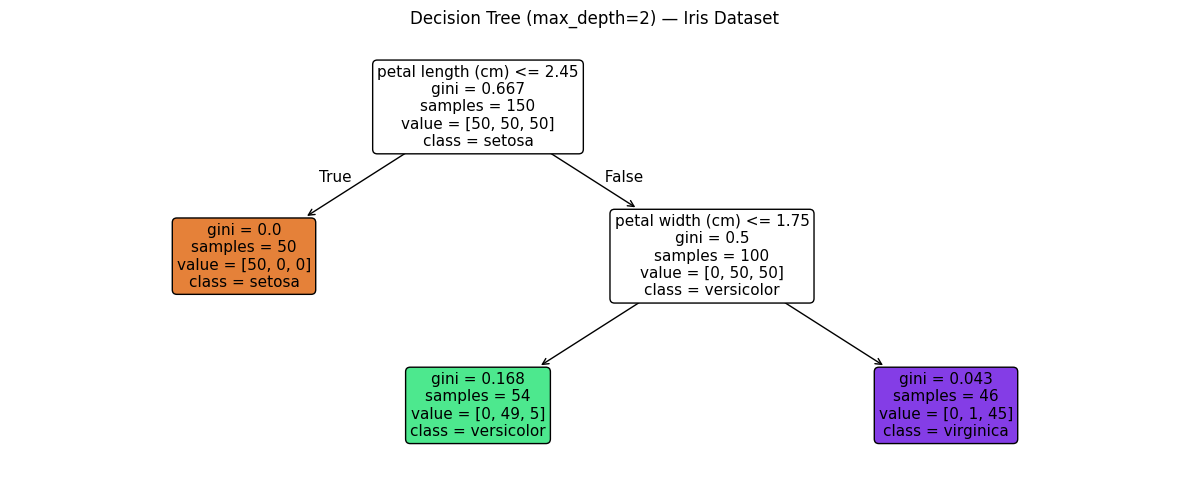

In [114]:
# -------------------------------------------------------
# EXPORT AND VISUALISE THE TREE
# export_graphviz creates a .dot file that can be rendered with Graphviz.
# Each node shows: split condition, gini impurity, sample count, and class.
# -------------------------------------------------------
import os
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 5))
plot_tree(
    tree_clf,
    feature_names=iris.feature_names[2:],  # petal length, petal width
    class_names=iris.target_names,
    filled=True,           # colour by majority class
    rounded=True,
    fontsize=11
)
plt.title('Decision Tree (max_depth=2) — Iris Dataset')
save_fig('decision_tree_plot')
plt.show()


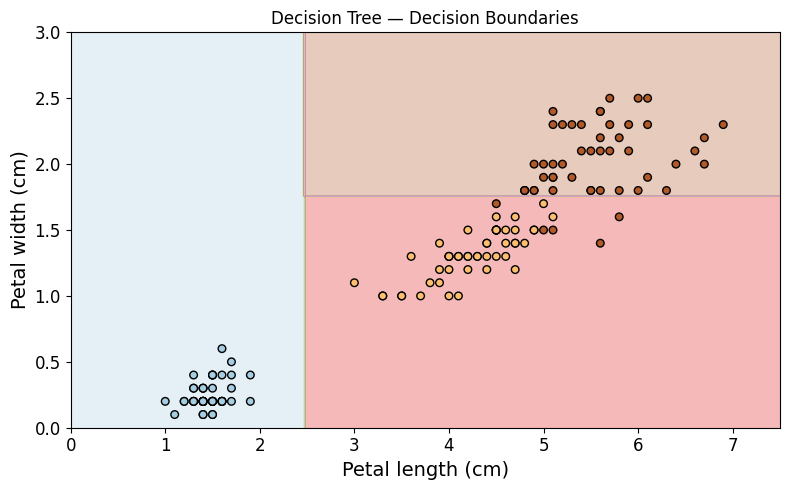

In [115]:
# -------------------------------------------------------
# DECISION BOUNDARY VISUALISATION
# Shows how the tree partitions the petal-length/petal-width space
# into rectangular regions, one per leaf.
# -------------------------------------------------------
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes, cmap='Paired'):
    """Plot decision regions for a 2-D feature space."""
    x1s = np.linspace(axes[0], axes[1], 200)
    x2s = np.linspace(axes[2], axes[3], 200)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, s=30, edgecolors='k')

plt.figure(figsize=(8, 5))
plot_decision_boundary(tree_clf, X_tree, y_tree, axes=[0, 7.5, 0, 3])
plt.xlabel('Petal length (cm)'); plt.ylabel('Petal width (cm)')
plt.title('Decision Tree — Decision Boundaries')
save_fig('decision_tree_decision_boundaries')
plt.show()


## 4.2 Gini Impurity vs Entropy

In [116]:
# -------------------------------------------------------
# GINI vs ENTROPY
# Gini impurity (default): faster to compute, similar results.
# Entropy (information gain): slightly slower, sometimes produces
# more balanced trees.
# Both measure 'impurity' at a node — lower is purer.
# -------------------------------------------------------
tree_clf_entropy = DecisionTreeClassifier(criterion='entropy',
                                           max_depth=2, random_state=42)
tree_clf_entropy.fit(X_tree, y_tree)

print('Gini tree predictions:   ',
      tree_clf.predict([[5, 1.5], [4, 0.5]]))
print('Entropy tree predictions:',
      tree_clf_entropy.predict([[5, 1.5], [4, 0.5]]))
# Usually identical; differences appear in edge cases.


Gini tree predictions:    [1 1]
Entropy tree predictions: [1 1]


## 4.3 Regularisation & Sensitivity to Data

In [117]:
# -------------------------------------------------------
# REGULARISATION HYPERPARAMETERS
# Without constraints, trees grow until leaves are pure → overfitting.
# Key knobs:
#   max_depth          — maximum tree depth
#   min_samples_split  — min samples required to split a node
#   min_samples_leaf   — min samples required in a leaf
#   max_features       — max features considered per split
#   max_leaf_nodes     — max number of leaves
# -------------------------------------------------------
from sklearn.datasets import make_moons as make_moons_dt

X_moons_dt, y_moons_dt = make_moons_dt(n_samples=10000, noise=0.4, random_state=42)

X_tr, X_te, y_tr, y_te = train_test_split(X_moons_dt, y_moons_dt,
                                            test_size=0.2, random_state=42)

# Unregularised tree (can easily overfit)
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_tr, y_tr)
print('Full tree  — train acc:', round(tree_full.score(X_tr, y_tr), 4),
      ' | test acc:', round(tree_full.score(X_te, y_te), 4))

# Regularised tree (better generalisation)
tree_reg = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
tree_reg.fit(X_tr, y_tr)
print('Reg tree   — train acc:', round(tree_reg.score(X_tr, y_tr), 4),
      ' | test acc:', round(tree_reg.score(X_te, y_te), 4))

Full tree  — train acc: 1.0  | test acc: 0.8145
Reg tree   — train acc: 0.9184  | test acc: 0.8265


## 4.4 Decision Tree Regression

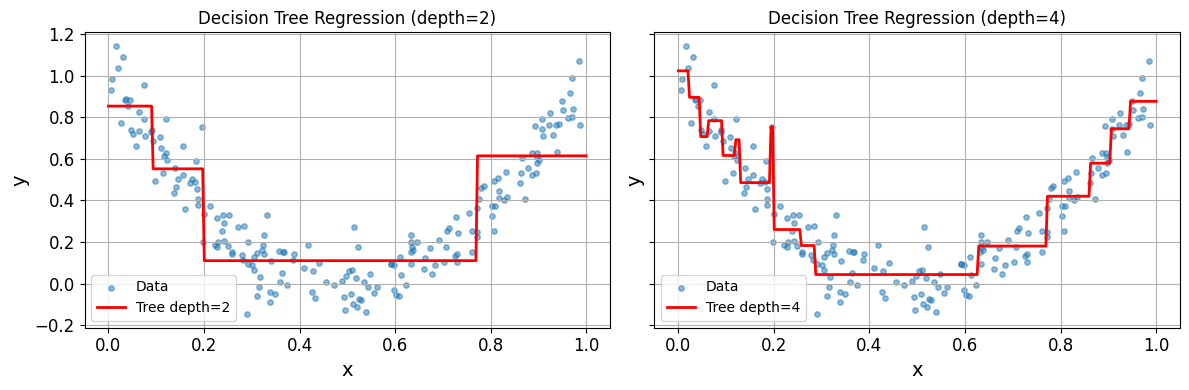

In [118]:
# -------------------------------------------------------
# DECISION TREE REGRESSION
# Instead of predicting a class, each leaf predicts the
# MEAN target value of the training samples that fell into it.
# Again, max_depth controls overfitting.
# -------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
m_dtr = 200
X_dtr = np.random.rand(m_dtr, 1)       # x ∈ [0, 1]
y_dtr = 4 * (X_dtr - 0.5)**2 + np.random.randn(m_dtr, 1) / 10  # quadratic target
y_dtr = y_dtr.ravel()

# Compare depth=2 vs depth=4
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
X_plot_dtr = np.linspace(0, 1, 300).reshape(-1, 1)

for ax, depth in zip(axes, [2, 4]):
    tree_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree_reg.fit(X_dtr, y_dtr)
    ax.scatter(X_dtr, y_dtr, s=15, alpha=0.5, label='Data')
    ax.plot(X_plot_dtr, tree_reg.predict(X_plot_dtr),
            'r-', linewidth=2, label=f'Tree depth={depth}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(); ax.grid(True)
    ax.set_title(f'Decision Tree Regression (depth={depth})')

save_fig('tree_regression_plot')
plt.tight_layout(); plt.show()


---
<a id='ch7'></a>
# 📓 Ensemble Learning and Random Forests

**Key concepts covered:**
- Voting classifiers (hard and soft voting)
- Bagging and Pasting — random subsets of data
- Random Forests — feature randomness + bagging
- Feature importance from forests
- Boosting: AdaBoost and Gradient Boosting
- Stacking


## 5.1 Voting Classifiers

In [119]:
# -------------------------------------------------------
# VOTING CLASSIFIER
# Combines multiple different models ('estimators').
# Hard voting: majority class wins.
# Soft voting: average predicted probabilities → more accurate when
#              models are well-calibrated.
# The ensemble often outperforms any individual model.
# -------------------------------------------------------
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score

X_vote, y_vote = make_moons(n_samples=500, noise=0.30, random_state=42)
X_tr_v, X_te_v, y_tr_v, y_te_v = train_test_split(
    X_vote, y_vote, test_size=0.2, random_state=42)

# Three diverse base estimators
log_clf   = LogisticRegression(solver='lbfgs', random_state=42)
rnd_clf   = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf_v = SVC(gamma='auto', random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf_v)],
    voting='hard'   # majority vote
)
voting_clf.fit(X_tr_v, y_tr_v)

# Compare individual vs ensemble accuracy
for clf in (log_clf, rnd_clf, svm_clf_v, voting_clf):
    clf.fit(X_tr_v, y_tr_v)
    y_pred_v = clf.predict(X_te_v)
    print(type(clf).__name__, '→ test accuracy:', round(accuracy_score(y_te_v, y_pred_v), 4))

LogisticRegression → test accuracy: 0.85
RandomForestClassifier → test accuracy: 0.88
SVC → test accuracy: 0.87
VotingClassifier → test accuracy: 0.87


## 5.2 Bagging and Pasting

In [120]:
# -------------------------------------------------------
# BAGGING (Bootstrap AGGregatING)
# Trains the SAME model on many different random subsets of the training data.
# Bagging: subsets sampled WITH replacement (bootstrap=True).
# Pasting:  subsets sampled WITHOUT replacement (bootstrap=False).
# Aggregation: majority vote (classification) or mean (regression).
# Reduces variance → helps with overfitting.
# -------------------------------------------------------
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # base learner
    n_estimators=500,           # 500 trees
    max_samples=100,            # each tree trained on 100 random samples
    bootstrap=True,             # with replacement
    random_state=42,
    n_jobs=-1                   # use all CPU cores
)
bag_clf.fit(X_tr_v, y_tr_v)
y_pred_bag = bag_clf.predict(X_te_v)
print('Bagging accuracy:', round(accuracy_score(y_te_v, y_pred_bag), 4))

Bagging accuracy: 0.9


In [121]:
# -------------------------------------------------------
# OUT-OF-BAG (OOB) EVALUATION
# With bootstrap sampling, on average ~37% of samples are never drawn
# for a given tree — these 'out-of-bag' samples can serve as a
# free validation set without needing an explicit holdout split.
# -------------------------------------------------------
bag_clf_oob = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    bootstrap=True,
    oob_score=True,   # automatically evaluate on OOB samples
    random_state=40,
    n_jobs=-1
)
bag_clf_oob.fit(X_tr_v, y_tr_v)
print('OOB score (free validation estimate):', round(bag_clf_oob.oob_score_, 4))
# Compare against the true test-set accuracy:
print('True test accuracy:                  ',
      round(accuracy_score(y_te_v, bag_clf_oob.predict(X_te_v)), 4))

OOB score (free validation estimate): 0.91
True test accuracy:                   0.88


## 5.3 Random Forests

In [122]:
# -------------------------------------------------------
# RANDOM FOREST CLASSIFIER
# A Random Forest is essentially a Bagging ensemble of Decision Trees,
# with an extra source of randomness:
# at each node split, only a RANDOM SUBSET of features is considered
# (max_features). This decorrelates the trees → even lower variance.
# -------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

rnd_clf_rf = RandomForestClassifier(
    n_estimators=500,   # 500 trees
    max_leaf_nodes=16,  # limit tree complexity
    random_state=42,
    n_jobs=-1
)
rnd_clf_rf.fit(X_tr_v, y_tr_v)

y_pred_rf = rnd_clf_rf.predict(X_te_v)
print('Random Forest accuracy:', round(accuracy_score(y_te_v, y_pred_rf), 4))

Random Forest accuracy: 0.89


  sepal length (cm)             : 0.1125
  sepal width (cm)              : 0.0231
  petal length (cm)             : 0.4410
  petal width (cm)              : 0.4234


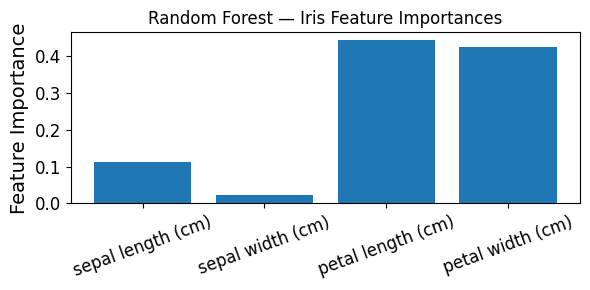

In [123]:
# -------------------------------------------------------
# FEATURE IMPORTANCE FROM RANDOM FORESTS
# Forests measure how much each feature reduces impurity across all trees.
# This gives a natural feature importance / ranking — very useful for
# feature selection and understanding the data.
# -------------------------------------------------------
# Demonstrate on Iris dataset (4 features)
iris_rf = datasets.load_iris()
rnd_clf_iris = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rnd_clf_iris.fit(iris_rf.data, iris_rf.target)

# feature_importances_ sums to 1.0
for name, score in zip(iris_rf.feature_names, rnd_clf_iris.feature_importances_):
    print(f'  {name:30s}: {score:.4f}')

# Visualise as a bar chart
plt.figure(figsize=(6, 3))
plt.bar(iris_rf.feature_names, rnd_clf_iris.feature_importances_)
plt.ylabel('Feature Importance'); plt.title('Random Forest — Iris Feature Importances')
plt.xticks(rotation=20)
save_fig('random_forest_feature_importance')
plt.tight_layout(); plt.show()


## 5.4 AdaBoost

In [124]:
# -------------------------------------------------------
# ADABOOST
# Boosting: sequentially trains models, each focusing on the
# mistakes of the previous one.
# AdaBoost (Adaptive Boosting):
#   1. Train a weak learner on weighted samples.
#   2. Increase the weight of misclassified samples.
#   3. Repeat, then combine all classifiers by weighted majority vote.
# learning_rate shrinks the contribution of each new classifier.
# -------------------------------------------------------
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # 'stumps' as weak learners
    n_estimators=200,
    algorithm='SAMME',    # Changed from 'SAMME.R' to 'SAMME'
    learning_rate=0.5,
    random_state=42
)
ada_clf.fit(X_tr_v, y_tr_v)
print('AdaBoost accuracy:', round(accuracy_score(y_te_v, ada_clf.predict(X_te_v)), 4))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost accuracy: 0.89


## 5.5 Gradient Boosting

Best n_estimators: 120


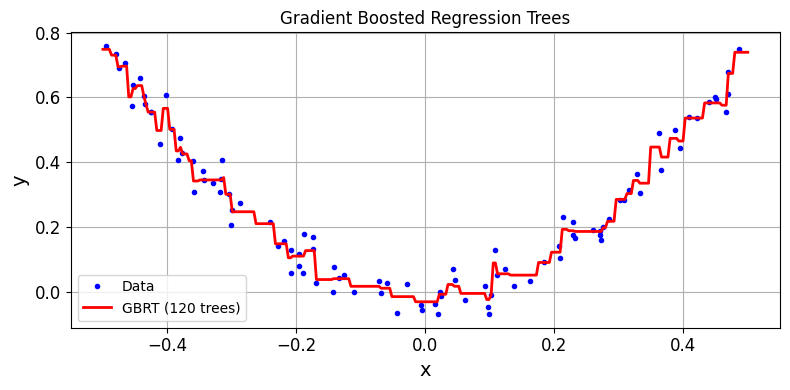

In [125]:
# -------------------------------------------------------
# GRADIENT BOOSTING (GBRT)
# Sequentially adds trees that each predict the RESIDUALS of the
# previous ensemble (gradient of the loss function).
# learning_rate shrinks the contribution of each tree (= shrinkage).
# n_estimators: number of trees — too many → overfitting.
# max_depth: depth of each tree (shallow trees = weak learners).
# -------------------------------------------------------
from sklearn.ensemble import GradientBoostingRegressor

np.random.seed(42)
X_gbr = np.random.rand(100, 1) - 0.5
y_gbr = 3 * X_gbr[:, 0]**2 + 0.05 * np.random.randn(100)

gbrt = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=120,
    learning_rate=0.1,
    random_state=42
)
gbrt.fit(X_gbr, y_gbr)

# Find optimal number of trees using staged predictions (avoid overfitting)
errors = [mean_squared_error(y_gbr, y_pred)
          for y_pred in gbrt.staged_predict(X_gbr)]
best_n_estimators = np.argmin(errors) + 1
print('Best n_estimators:', best_n_estimators)

# Refit with the optimal number of trees
gbrt_best = GradientBoostingRegressor(
    max_depth=2, n_estimators=best_n_estimators,
    learning_rate=0.1, random_state=42)
gbrt_best.fit(X_gbr, y_gbr)

X_plot_gbr = np.linspace(-0.5, 0.5, 300).reshape(-1, 1)
plt.figure(figsize=(8, 4))
plt.plot(X_gbr, y_gbr, 'b.', label='Data')
plt.plot(X_plot_gbr, gbrt_best.predict(X_plot_gbr), 'r-',
         linewidth=2, label=f'GBRT ({best_n_estimators} trees)')
plt.legend(); plt.xlabel('x'); plt.ylabel('y'); plt.grid(True)
plt.title('Gradient Boosted Regression Trees')
save_fig('gradient_boosting_plot')
plt.show()


## 5.6 Stacking

In [126]:
# -------------------------------------------------------
# STACKING (Stacked Generalisation)
# Train multiple base learners (layer 1), then train a 'blender'
# (meta-learner, layer 2) on the base learners' OUT-OF-FOLD predictions.
# The blender learns how to combine base predictions optimally.
# StackingClassifier in sklearn handles this end-to-end.
# -------------------------------------------------------
from sklearn.ensemble import StackingClassifier

estimators_stack = [
    ('rf',  RandomForestClassifier(n_estimators=10, random_state=42)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42)),
]

# The final_estimator is the blender / meta-learner
stacking_clf = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LogisticRegression(),
    cv=5      # use 5-fold CV to generate meta-features
)
stacking_clf.fit(X_tr_v, y_tr_v)
print('Stacking accuracy:', round(accuracy_score(y_te_v, stacking_clf.predict(X_te_v)), 4))

Stacking accuracy: 0.89


---
<a id='ch8'></a>
# 📔 Dimensionality Reduction

**Key concepts covered:**
- The curse of dimensionality
- PCA (Principal Component Analysis): explained variance, projections
- Kernel PCA for nonlinear dimensionality reduction
- Locally Linear Embedding (LLE) — manifold learning
- t-SNE for 2-D visualisation


## 6.1 Principal Component Analysis (PCA)

In [127]:
# -------------------------------------------------------
# PCA — PRINCIPAL COMPONENT ANALYSIS
# PCA finds the directions (principal components) of maximum variance,
# then projects data onto the top k components.
# Useful for:
#   - Compression / reducing storage
#   - Speeding up downstream models
#   - Visualisation (projecting to 2D or 3D)
#   - Removing noise (lower components often capture noise)
# -------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.datasets import make_swiss_roll

# Simple 3-D synthetic dataset
np.random.seed(4)
m_pca = 60
w1, w2 = 0.1, 0.3
noise = 0.1

angles = np.random.rand(m_pca) * 3 * np.pi / 2 - 0.5
X_3d = np.empty((m_pca, 3))
X_3d[:, 0] = np.cos(angles) + np.sin(angles) / 2 + noise * np.random.randn(m_pca) / 2
X_3d[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m_pca) / 2
X_3d[:, 2] = X_3d[:, 0] * w1 + X_3d[:, 1] * w2 + noise * np.random.randn(m_pca)

# Fit PCA: project from 3-D to 2-D (keep top 2 principal components)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_3d)

print('Original shape:', X_3d.shape, '→ Reduced shape:', X_2d.shape)
print('Explained variance ratios:', pca.explained_variance_ratio_.round(4))
print('Total explained variance:', pca.explained_variance_ratio_.sum().round(4))


Original shape: (60, 3) → Reduced shape: (60, 2)
Explained variance ratios: [0.8425 0.1463]
Total explained variance: 0.9888


Number of components to retain 95% variance: 148


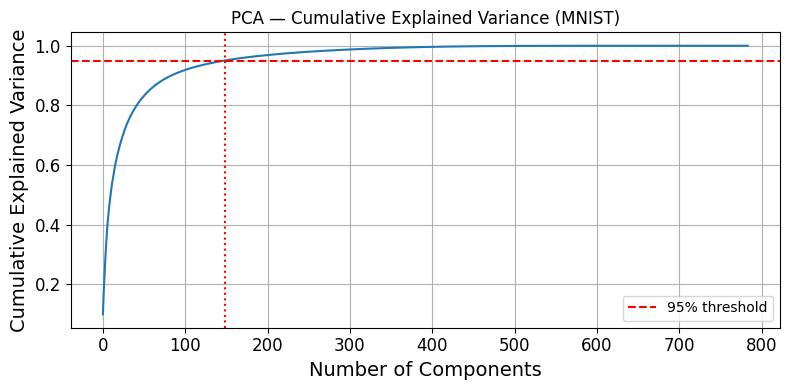

In [128]:
# -------------------------------------------------------
# CHOOSING THE NUMBER OF COMPONENTS VIA EXPLAINED VARIANCE
# Plot cumulative explained variance vs number of components.
# A common strategy: keep enough components to explain 95% of variance.
# -------------------------------------------------------
from sklearn.datasets import fetch_openml

# Use MNIST for a realistic high-dimensional example
# (already loaded above as X, y)
pca_full = PCA()   # no n_components → keeps all
pca_full.fit(X_train[:5000].astype(float))  # fit on a subset for speed

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Find k where 95% of variance is explained
d = np.argmax(cumvar >= 0.95) + 1
print(f'Number of components to retain 95% variance: {d}')

plt.figure(figsize=(8, 4))
plt.plot(cumvar)
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(d, color='r', linestyle=':')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Explained Variance')
plt.legend(); plt.grid(True)
plt.title('PCA — Cumulative Explained Variance (MNIST)')
save_fig('pca_explained_variance')
plt.show()


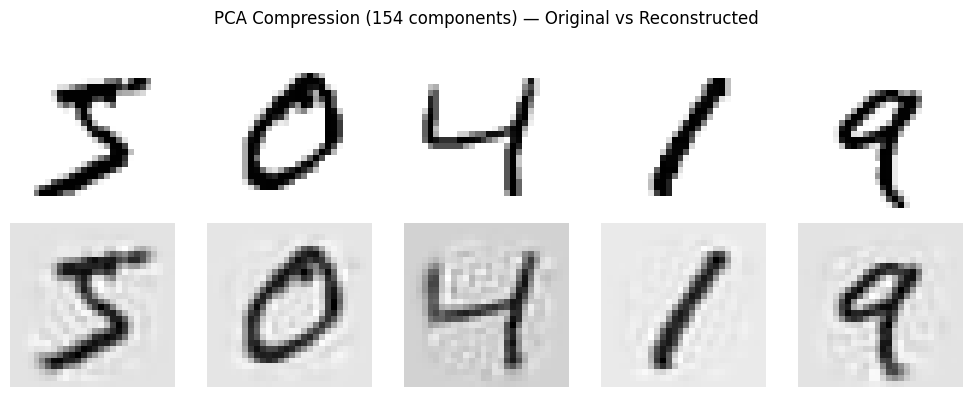

In [129]:
# -------------------------------------------------------
# PCA COMPRESSION AND RECONSTRUCTION (MNIST)
# Compress MNIST from 784 to 154 dimensions, then reconstruct.
# The reconstruction is slightly blurry — information has been lost.
# -------------------------------------------------------
pca_compress = PCA(n_components=154)   # 95% explained variance
X_train_pca = pca_compress.fit_transform(X_train[:5000].astype(float))

# Reconstruct: project back to original 784-D space
X_reconstructed = pca_compress.inverse_transform(X_train_pca)

# Compare original vs reconstructed
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap='binary')
    axes[0, i].axis('off')
    axes[1, i].imshow(X_reconstructed[i].reshape(28, 28), cmap='binary')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Reconstructed', fontsize=12)
plt.suptitle('PCA Compression (154 components) — Original vs Reconstructed')
save_fig('pca_compression_plot')
plt.show()


## 6.2 Kernel PCA (Non-linear Dimensionality Reduction)

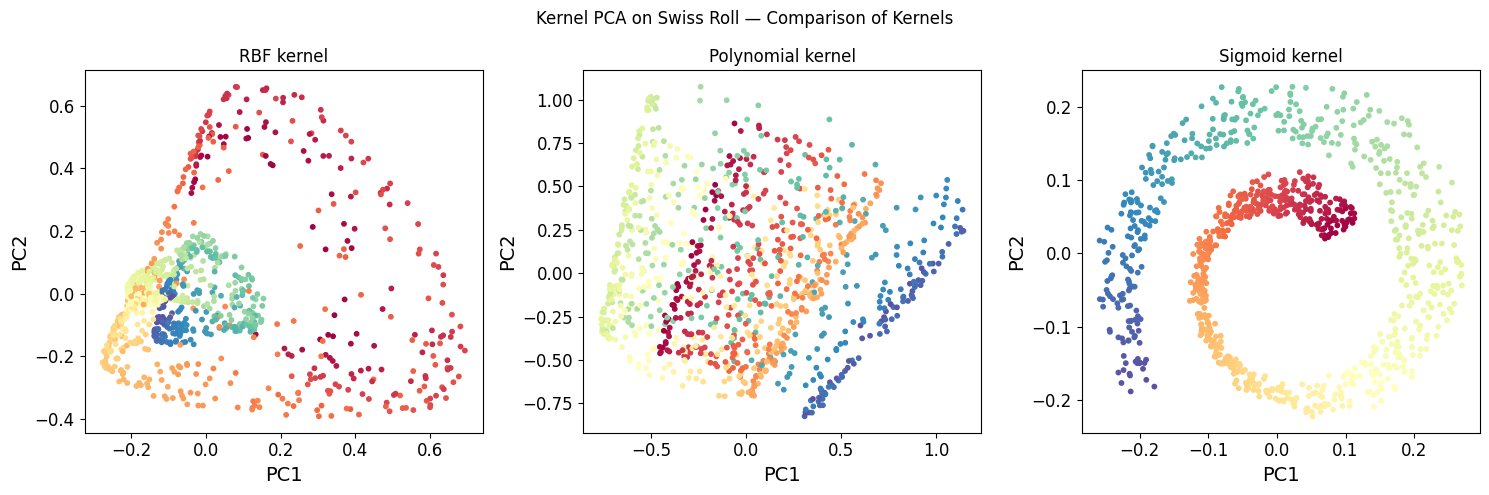

In [130]:
# -------------------------------------------------------
# KERNEL PCA
# Standard PCA is a linear method — it cannot 'unroll' nonlinear
# manifolds like the Swiss Roll.
# KernelPCA uses the kernel trick (same as SVM) to perform PCA
# in an implicit high-dimensional feature space,
# effectively finding nonlinear projections.
# Common kernels: rbf, poly, sigmoid, cosine
# -------------------------------------------------------
from sklearn.decomposition import KernelPCA
from sklearn.datasets import make_swiss_roll

X_swiss, t_swiss = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

# Apply three kernel types and compare 2-D projections
kernels = [('RBF kernel',       KernelPCA(n_components=2, kernel='rbf',    gamma=0.04)),
           ('Polynomial kernel',KernelPCA(n_components=2, kernel='poly',   gamma=0.001)),
           ('Sigmoid kernel',   KernelPCA(n_components=2, kernel='sigmoid',gamma=0.001))]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, kpca) in zip(axes, kernels):
    X_kpca = kpca.fit_transform(X_swiss)
    ax.scatter(X_kpca[:, 0], X_kpca[:, 1], c=t_swiss, cmap='Spectral', s=10)
    ax.set_title(label); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Kernel PCA on Swiss Roll — Comparison of Kernels')
save_fig('kernel_pca_plot')
plt.tight_layout(); plt.show()


## 6.3 Locally Linear Embedding (LLE)

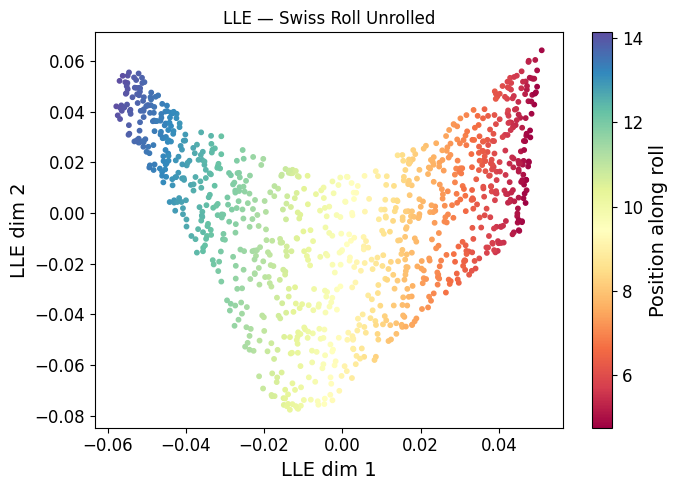

In [131]:
# -------------------------------------------------------
# LOCALLY LINEAR EMBEDDING (LLE) — Manifold Learning
# LLE is a nonlinear, unsupervised manifold learning technique.
# It 'unrolls' low-dimensional manifolds embedded in high-D space.
# Steps:
#   1. For each point, find k nearest neighbours.
#   2. Reconstruct each point as a weighted sum of its neighbours.
#   3. Find a low-D embedding that preserves these local relationships.
# Works well on well-structured manifolds (Swiss Roll, etc.).
# -------------------------------------------------------
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_lle = lle.fit_transform(X_swiss)

plt.figure(figsize=(7, 5))
plt.scatter(X_lle[:, 0], X_lle[:, 1], c=t_swiss, cmap='Spectral', s=10)
plt.colorbar(label='Position along roll')
plt.xlabel('LLE dim 1'); plt.ylabel('LLE dim 2')
plt.title('LLE — Swiss Roll Unrolled')
save_fig('lle_unrolling_plot')
plt.show()


## 6.4 t-SNE — 2-D Visualisation

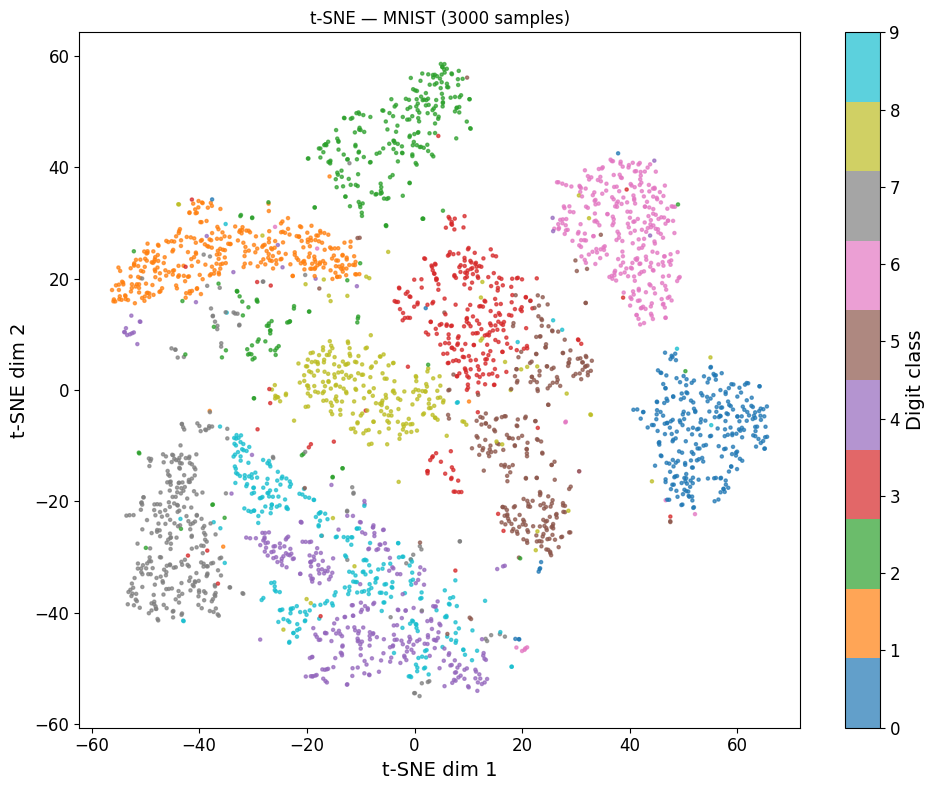

In [132]:
# -------------------------------------------------------
# t-SNE (t-Distributed Stochastic Neighbour Embedding)
# t-SNE is primarily a VISUALISATION tool, not for dimensionality
# reduction for machine learning tasks.
# It preserves LOCAL structure — nearby points in the original space
# remain nearby in 2D — making clusters clearly visible.
# perplexity (5–50) controls the balance between local/global structure.
# NOTE: t-SNE is stochastic and slow on large datasets.
# -------------------------------------------------------
from sklearn.manifold import TSNE

# Use a small MNIST sample for speed
X_tsne = X[:3000].astype(float)
y_tsne = y[:3000]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d_tsne = tsne.fit_transform(X_tsne)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d_tsne[:, 0], X_2d_tsne[:, 1],
                      c=y_tsne, cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Digit class')
plt.xlabel('t-SNE dim 1'); plt.ylabel('t-SNE dim 2')
plt.title('t-SNE — MNIST (3000 samples)')
save_fig('tsne_mnist_plot')
plt.show()


---
<a id='extra-clf'></a>
# 📘 Classification Algorithms

Algorithms from the research curriculum **not covered** in Chapters 3–8.


## 7.1 Naive Bayes

**Theory:** A probabilistic classifier based on Bayes' Theorem. Called "naive" because it assumes
all features are independent of each other.

- **Gaussian NB** — features follow normal distribution (continuous data)
- **Multinomial NB** — for count data (e.g. text classification)
- **Bernoulli NB** — for binary features

**Real-world use:** Email spam detection, sentiment analysis, medical diagnosis.

**Key Math:**
```
Bayes' Theorem:    P(C|X) = P(X|C) · P(C) / P(X)
Naive assumption:  P(X|C) = P(x₁|C) · P(x₂|C) · ... · P(xₙ|C)
Prediction:        ŷ = argmax P(C) · ∏P(xᵢ|C)
```


In [133]:
# -------------------------------------------------------
# NAIVE BAYES — THREE VARIANTS
# Naive Bayes is extremely fast and works surprisingly well
# even when the 'naive' independence assumption is violated.
# -------------------------------------------------------
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

iris = load_iris()
X_nb, y_nb = iris.data, iris.target
X_tr_nb, X_te_nb, y_tr_nb, y_te_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42)

# --- Gaussian NB ---
# Assumes each feature is normally distributed within each class.
# Good for continuous features like measurements.
gnb = GaussianNB()
gnb.fit(X_tr_nb, y_tr_nb)
print(f'Gaussian NB Accuracy:     {accuracy_score(y_te_nb, gnb.predict(X_te_nb)):.3f}')

# --- Bernoulli NB ---
# Designed for binary/boolean features (present or absent).
# Binarise the iris features first (above/below median) as demonstration.
from sklearn.preprocessing import Binarizer
bnb = BernoulliNB()
X_bin = Binarizer().fit_transform(X_tr_nb)
X_bin_te = Binarizer().fit_transform(X_te_nb)
bnb.fit(X_bin, y_tr_nb)
print(f'Bernoulli NB Accuracy:    {accuracy_score(y_te_nb, bnb.predict(X_bin_te)):.3f}')

# --- Spam Detection with Multinomial NB ---
# Multinomial NB is the go-to algorithm for text classification.
# Works on word COUNT vectors (non-negative integers).
from sklearn.feature_extraction.text import CountVectorizer

emails = [
    'Get rich quick! Buy now!',
    'Meeting at 3pm tomorrow',
    'Win a free iPhone now!!!',
    'Quarterly report attached',
    'URGENT: Claim your prize',
    'Team lunch on Friday',
    'Free money click here now',
    'Project deadline reminder',
]
labels = [1, 0, 1, 0, 1, 0, 1, 0]  # 1 = spam, 0 = ham

# CountVectorizer converts text to word-count matrix
vectorizer = CountVectorizer()
X_email = vectorizer.fit_transform(emails)

mnb = MultinomialNB(alpha=1.0)  # alpha = Laplace smoothing (avoids zero probability)
mnb.fit(X_email, labels)

test_emails = ['Free cash prize click here', 'Budget meeting next week']
X_test_email = vectorizer.transform(test_emails)
preds = mnb.predict(X_test_email)
probs = mnb.predict_proba(X_test_email)

print('\nSpam Detection (Multinomial NB):')
for email, pred, prob in zip(test_emails, preds, probs):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f'  "{email[:35]}" → {label} (spam prob: {prob[1]:.2%})')


Gaussian NB Accuracy:     1.000
Bernoulli NB Accuracy:    0.300

Spam Detection (Multinomial NB):
  "Free cash prize click here" → SPAM (spam prob: 94.39%)
  "Budget meeting next week" → HAM (spam prob: 31.39%)


### 7.2 AdaBoost (Adaptive Boosting) — Classifier

**Theory:** Combines multiple **weak classifiers** (decision stumps) sequentially.
Each new classifier focuses on the samples the previous one got wrong by increasing their weights.

- Misclassified samples get **higher weight** → next classifier focuses on them
- Final prediction = **weighted majority vote** of all weak classifiers
- `algorithm='SAMME.R'` uses probabilities → faster convergence than `SAMME`

**Real-world use:** Face detection (Viola-Jones), fraud detection, medical imaging.

**Key Math:**
```
Error:          εₜ = Σ wᵢ · I(yᵢ ≠ hₜ(xᵢ))
Classifier wt:  αₜ = (1/2) ln((1-εₜ)/εₜ)
Weight update:  wᵢ⁺¹ = wᵢ · exp(-αₜ · yᵢ · hₜ(xᵢ))
Final vote:     H(x) = sign(Σ αₜ · hₜ(x))
```


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost Accuracy: 0.890


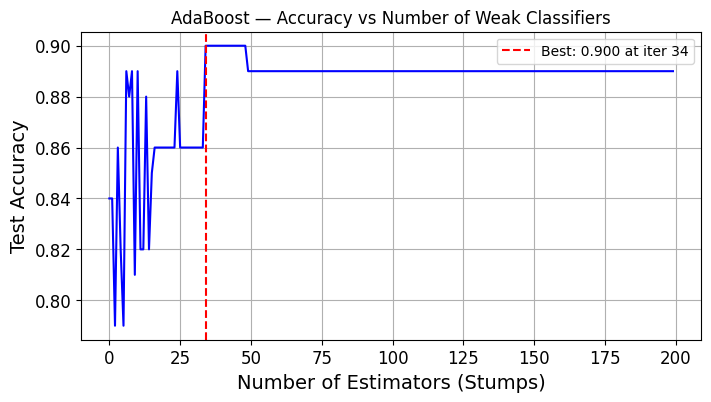

Peak accuracy: 0.900 at estimator #34


In [134]:
# -------------------------------------------------------
# ADABOOST CLASSIFIER
# Decision stumps (max_depth=1) are the default 'weak learners'.
# n_estimators: how many stumps to combine.
# learning_rate: shrinks the contribution of each stump (trade-off with n_estimators).
# -------------------------------------------------------
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

X_ada, y_ada = make_moons(n_samples=500, noise=0.30, random_state=42)
X_tr_ada, X_te_ada, y_tr_ada, y_te_ada = train_test_split(
    X_ada, y_ada, test_size=0.2, random_state=42)

# Train AdaBoost with decision stumps as weak learners
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # 'stump' = depth-1 tree
    n_estimators=200,       # combine 200 stumps
    learning_rate=0.5,      # shrinkage; lower = needs more estimators but more robust
    algorithm='SAMME',    # Changed from 'SAMME.R' to 'SAMME'
    random_state=42
)
ada_clf.fit(X_tr_ada, y_tr_ada)
print(f'AdaBoost Accuracy: {accuracy_score(y_te_ada, ada_clf.predict(X_te_ada)):.3f}')

# Show how accuracy improves as more estimators are added
# staged_predict() gives predictions at each boosting stage
staged_scores = [
    accuracy_score(y_te_ada, y_pred)
    for y_pred in ada_clf.staged_predict(X_te_ada)
]

plt.figure(figsize=(8, 4))
plt.plot(staged_scores, 'b-', linewidth=1.5)
plt.xlabel('Number of Estimators (Stumps)')
plt.ylabel('Test Accuracy')
plt.title('AdaBoost — Accuracy vs Number of Weak Classifiers')
plt.grid(True)
plt.axvline(np.argmax(staged_scores), color='r', linestyle='--', label=f'Best: {max(staged_scores):.3f} at iter {np.argmax(staged_scores)}')
plt.legend()
plt.show()
print(f'Peak accuracy: {max(staged_scores):.3f} at estimator #{np.argmax(staged_scores)}')


## 7.3 Linear Discriminant Analysis (LDA)

**Theory:** Finds a linear combination of features that **maximally separates** classes.
It projects data onto a lower-dimensional space where classes are best separated.

- Dual purpose: **classification** AND **dimensionality reduction** (like PCA but supervised)
- Assumes features follow Gaussian distribution with equal class covariance
- Maximises **between-class variance / within-class variance** ratio

**Real-world use:** Face recognition, medical diagnosis, customer segmentation.

**Key Math:**
```
Between-class scatter:  Sᵦ = Σ Nᵢ(μᵢ - μ)(μᵢ - μ)ᵀ
Within-class scatter:   Sᵥ = Σ (x - μᵢ)(x - μᵢ)ᵀ
Objective:              Maximise J(w) = (wᵀSᵦw) / (wᵀSᵥw)
Decision:               Classify to class k where δₖ(x) is maximum
```


LDA Classifier:
  Accuracy: 1.000



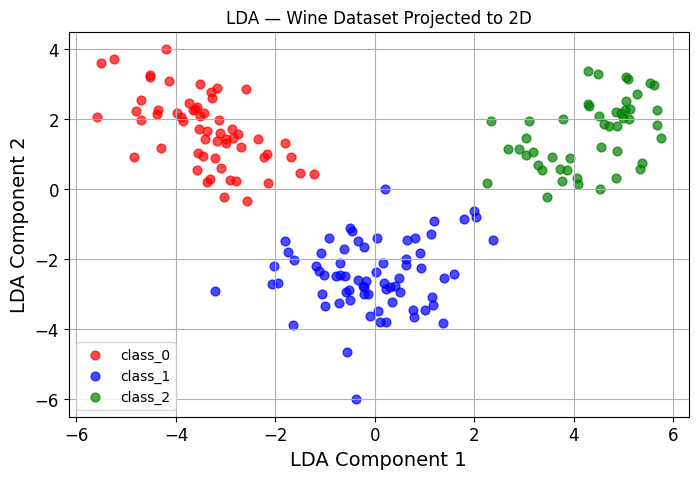

LDA reduces 13 features → 2 discriminant components while separating classes clearly.


In [135]:
# -------------------------------------------------------
# LINEAR DISCRIMINANT ANALYSIS (LDA)
# LDA can be used in two ways:
#   1. As a CLASSIFIER: predict class labels directly
#   2. As DIMENSIONALITY REDUCTION: project to k-1 dimensions
#      (k = number of classes)
# -------------------------------------------------------
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Wine dataset: 3 classes, 13 features — perfect for LDA demo
wine = load_wine()
X_lda, y_lda = wine.data, wine.target
X_tr_lda, X_te_lda, y_tr_lda, y_te_lda = train_test_split(
    X_lda, y_lda, test_size=0.2, random_state=42)

# --- LDA as CLASSIFIER ---
lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_tr_lda, y_tr_lda)
y_pred_lda = lda_clf.predict(X_te_lda)
print('LDA Classifier:')
print(f'  Accuracy: {accuracy_score(y_te_lda, y_pred_lda):.3f}')
print()

# --- LDA as DIMENSIONALITY REDUCTION ---
# For k classes, LDA can reduce to at most k-1 dimensions.
# Here: 3 wine classes → project to 2 LDA components for visualisation.
lda_2d = LinearDiscriminantAnalysis(n_components=2)
X_lda_2d = lda_2d.fit_transform(X_lda, y_lda)  # supervised projection

plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green']
for cls, color, name in zip([0, 1, 2], colors, wine.target_names):
    mask = y_lda == cls
    plt.scatter(X_lda_2d[mask, 0], X_lda_2d[mask, 1],
                color=color, label=name, alpha=0.7, s=40)
plt.xlabel('LDA Component 1'); plt.ylabel('LDA Component 2')
plt.title('LDA — Wine Dataset Projected to 2D')
plt.legend(); plt.grid(True)
plt.show()
print('LDA reduces 13 features → 2 discriminant components while separating classes clearly.')


## 7.4 Gradient Boosting Classifier (XGBoost-style)

**Theory:** Builds trees **sequentially** where each tree corrects the errors of all previous trees.
Unlike AdaBoost (sample reweighting), Gradient Boosting fits each new tree to the **residuals (gradients)** of the loss function.

- Boosting: weak learners → strong learner
- Uses **gradient descent** to minimise a loss function
- Popular implementations: **XGBoost**, **LightGBM**, **CatBoost**

**Real-world use:** Winning algorithm on structured/tabular data competitions (Kaggle), credit scoring, click prediction.

**Key Math:**
```
F₀(x) = initial prediction
For m = 1 to M:
  rᵢₘ = -[∂L(yᵢ, F(xᵢ)) / ∂F(xᵢ)]   ← negative gradient (residuals)
  Fit tree hₘ to residuals
  Fₘ(x) = Fₘ₋₁(x) + η·hₘ(x)         ← update model
Final: ŷ = F₀ + η·h₁ + η·h₂ + ... + η·hₘ
```


In [136]:
# -------------------------------------------------------
# GRADIENT BOOSTING CLASSIFIER
# Key hyperparameters:
#   n_estimators: number of trees (too many → overfit)
#   learning_rate: shrinkage per tree (lower = needs more trees)
#   max_depth: depth of each tree (shallow trees = weak learners)
#   subsample: fraction of samples per tree (< 1.0 = stochastic GB)
# -------------------------------------------------------
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer

# Breast cancer dataset: binary classification (malignant vs benign)
cancer = load_breast_cancer()
X_gbc, y_gbc = cancer.data, cancer.target
X_tr_gbc, X_te_gbc, y_tr_gbc, y_te_gbc = train_test_split(
    X_gbc, y_gbc, test_size=0.2, random_state=42)

gbc = GradientBoostingClassifier(
    n_estimators=100,      # 100 trees
    learning_rate=0.1,     # each tree contributes 10% (shrinkage)
    max_depth=3,           # shallow trees prevent overfitting
    subsample=0.8,         # use 80% of data per tree (stochastic boosting)
    random_state=42
)
gbc.fit(X_tr_gbc, y_tr_gbc)
print(f'Gradient Boosting Classifier Accuracy: {accuracy_score(y_te_gbc, gbc.predict(X_te_gbc)):.3f}')

# Compare with other classifiers on the same dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    'Gradient Boosting': gbc,
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': Pipeline([('sc', StandardScaler()),
                                      ('lr', LogisticRegression(max_iter=1000))]),
}
print('\nComparison on Breast Cancer Dataset:')
for name, model in models.items():
    model.fit(X_tr_gbc, y_tr_gbc)
    acc = accuracy_score(y_te_gbc, model.predict(X_te_gbc))
    print(f'  {name:25s}: {acc:.3f}')


Gradient Boosting Classifier Accuracy: 0.956

Comparison on Breast Cancer Dataset:
  Gradient Boosting        : 0.956
  Random Forest            : 0.965
  Logistic Regression      : 0.974


---
<a id='regression-full'></a>
# 📙 Regression Algorithms (Complete Reference)

All regression algorithms from the Research Intake curriculum.
Section 4 covered Linear Regression basics; this section adds the **full set**.


## 8.1 Polynomial Regression

**Theory:** Extends linear regression by adding polynomial features (x², x³, ...).
Still fits a **linear model** in the parameter space — just on transformed features.

- Captures non-linear (curved) relationships
- Higher degree = more flexible but risks **overfitting**
- Always use with regularisation (Ridge/Lasso) for high degrees

**Key Math:**
```
y = β₀ + β₁x + β₂x² + ... + βₙxⁿ + ε
Same MSE cost function as linear regression after feature expansion
```


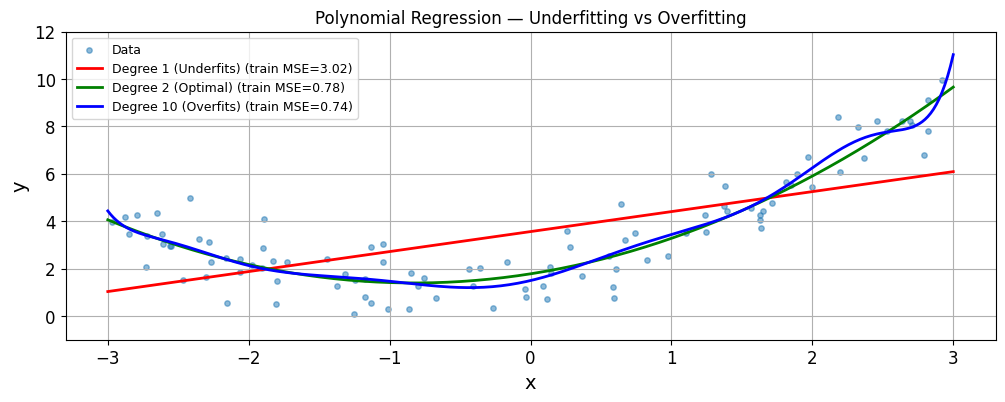

In [137]:
# -------------------------------------------------------
# POLYNOMIAL REGRESSION — DEGREE COMPARISON
# PolynomialFeatures(degree=d) creates all polynomial combinations
# up to degree d: [x] → [1, x, x², x³, ...]
# -------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100
X_poly = 6 * np.random.rand(m, 1) - 3      # x ∈ [-3, 3]
y_poly = 0.5 * X_poly**2 + X_poly + 2 + np.random.randn(m, 1)  # quadratic true function

X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.figure(figsize=(12, 4))
plt.scatter(X_poly, y_poly, s=15, alpha=0.5, label='Data')

# Compare degree 1 (underfit), degree 2 (just right), degree 10 (overfit)
for degree, color, label in [(1, 'red', 'Degree 1 (Underfits)'),
                               (2, 'green', 'Degree 2 (Optimal)'),
                               (10, 'blue', 'Degree 10 (Overfits)')]:
    poly_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    poly_pipe.fit(X_poly, y_poly.ravel())
    y_plot = poly_pipe.predict(X_plot)
    train_mse = mean_squared_error(y_poly, poly_pipe.predict(X_poly))
    plt.plot(X_plot, y_plot, color=color, linewidth=2,
             label=f'{label} (train MSE={train_mse:.2f})')

plt.ylim(-1, 12); plt.xlabel('x'); plt.ylabel('y')
plt.title('Polynomial Regression — Underfitting vs Overfitting')
plt.legend(fontsize=9); plt.grid(True)
plt.show()


## 8.2 Ridge Regression (L2 Regularisation)

**Theory:** Adds an **L2 penalty** (sum of squared coefficients) to the MSE loss.
Prevents any single feature from dominating; shrinks all coefficients toward zero but **never to exactly zero**.

- **When to use:** Many correlated features; prevents overfitting in high-dimensional data
- `alpha` (= λ) controls regularisation strength: higher → more shrinkage

**Key Math:**
```
J(β) = MSE + λ Σβⱼ²
Closed form: β = (XᵀX + λI)⁻¹Xᵀy
```


In [138]:
# -------------------------------------------------------
# RIDGE REGRESSION — EFFECT OF ALPHA (lambda)
# Alpha = 0 → ordinary linear regression (no regularisation)
# Alpha → ∞ → all coefficients shrink to zero
# -------------------------------------------------------
from sklearn.linear_model import Ridge
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)

# Scale features — Ridge is sensitive to feature scale
scaler = StandardScaler()
X_tr_hs = scaler.fit_transform(X_tr_h)  # fit only on train to avoid data leakage
X_te_hs = scaler.transform(X_te_h)

print('Ridge Regression — Effect of Alpha:')
for alpha in [0, 0.1, 1.0, 10.0, 100.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_tr_hs, y_tr_h)
    r2 = r2_score(y_te_h, ridge.predict(X_te_hs))
    coef_norm = np.linalg.norm(ridge.coef_)  # L2 norm of coefficients
    print(f'  alpha={alpha:6.1f}  →  R²={r2:.4f}  |  ||coef||={coef_norm:.4f}')
print('Note: As alpha increases, coefficients shrink (||coef|| decreases).')


Ridge Regression — Effect of Alpha:
  alpha=   0.0  →  R²=0.5758  |  ||coef||=1.5842
  alpha=   0.1  →  R²=0.5758  |  ||coef||=1.5841
  alpha=   1.0  →  R²=0.5758  |  ||coef||=1.5832
  alpha=  10.0  →  R²=0.5761  |  ||coef||=1.5745
  alpha= 100.0  →  R²=0.5778  |  ||coef||=1.4955
Note: As alpha increases, coefficients shrink (||coef|| decreases).


## 8.3 Lasso Regression (L1 Regularisation)

**Theory:** Adds an **L1 penalty** (sum of absolute coefficients).
Unlike Ridge, Lasso can drive some coefficients to **exactly zero** → automatic **feature selection**.

- **When to use:** High-dimensional data where many features are irrelevant; you want a **sparse model**
- Use `alpha` to control how many features survive

**Key Math:**
```
J(β) = MSE + λ Σ|βⱼ|
No closed-form → solved via coordinate descent or proximal gradient
```


Lasso R² (alpha=0.1): 0.4814
Features used (non-zero coef): 3 / 8



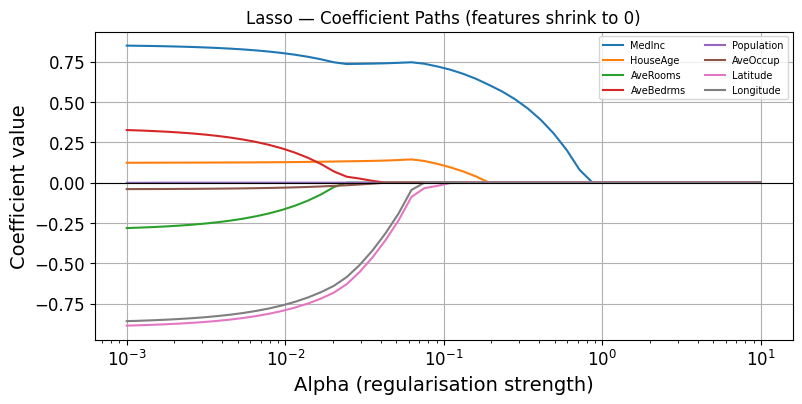

In [139]:
# -------------------------------------------------------
# LASSO REGRESSION — FEATURE SELECTION PROPERTY
# The key difference from Ridge: Lasso sets some coefficients
# to EXACTLY zero, effectively removing those features.
# -------------------------------------------------------
from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_tr_hs, y_tr_h)
r2_lasso = r2_score(y_te_h, lasso.predict(X_te_hs))

print(f'Lasso R² (alpha=0.1): {r2_lasso:.4f}')
print(f'Features used (non-zero coef): {np.sum(lasso.coef_ != 0)} / {len(lasso.coef_)}')
print()

# Show feature importance: how Lasso zeroes out features as alpha increases
alphas = np.logspace(-3, 1, 50)
coefs = []
for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=10000)
    l.fit(X_tr_hs, y_tr_h)
    coefs.append(l.coef_.copy())
coefs = np.array(coefs)

plt.figure(figsize=(9, 4))
for j in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, j], label=housing.feature_names[j])
plt.xscale('log')
plt.xlabel('Alpha (regularisation strength)'); plt.ylabel('Coefficient value')
plt.title('Lasso — Coefficient Paths (features shrink to 0)')
plt.axhline(0, color='k', linewidth=0.8)
plt.legend(fontsize=7, ncol=2); plt.grid(True)
plt.show()


## 8.4 Elastic Net

**Theory:** Hybrid of Ridge (L2) and Lasso (L1). Gets the best of both worlds:
- **Feature selection** (from Lasso)
- **Handles correlated features** well (from Ridge — keeps groups together)

- `l1_ratio=0` → pure Ridge; `l1_ratio=1` → pure Lasso; `0 < l1_ratio < 1` → Elastic Net
- Preferred over pure Lasso when features are correlated

**Key Math:**
```
J(β) = MSE + λ[r·Σ|βⱼ| + (1-r)/2·Σβⱼ²]
         ↑            ↑ L1         ↑ L2
         λ = overall  r = l1_ratio
```


In [140]:
# -------------------------------------------------------
# ELASTIC NET — COMBINING L1 + L2 PENALTIES
# l1_ratio controls the mix:
#   0.0 → pure Ridge (all features kept, no selection)
#   1.0 → pure Lasso (maximum feature selection)
#   0.5 → balanced mix (default)
# -------------------------------------------------------
from sklearn.linear_model import ElasticNet

print('Elastic Net — Effect of l1_ratio:')
for l1_ratio in [0.0, 0.2, 0.5, 0.8, 1.0]:
    en = ElasticNet(alpha=0.1, l1_ratio=l1_ratio, max_iter=10000)
    en.fit(X_tr_hs, y_tr_h)
    r2 = r2_score(y_te_h, en.predict(X_te_hs))
    n_zero = np.sum(en.coef_ == 0)
    print(f'  l1_ratio={l1_ratio:.1f}  →  R²={r2:.4f} | Zero coefs: {n_zero}/{len(en.coef_)}')

print('\nl1_ratio=0.0 (Ridge): no zeros | l1_ratio=1.0 (Lasso): most zeros')


Elastic Net — Effect of l1_ratio:
  l1_ratio=0.0  →  R²=0.5557 | Zero coefs: 0/8
  l1_ratio=0.2  →  R²=0.5411 | Zero coefs: 2/8
  l1_ratio=0.5  →  R²=0.5148 | Zero coefs: 4/8
  l1_ratio=0.8  →  R²=0.4873 | Zero coefs: 5/8
  l1_ratio=1.0  →  R²=0.4814 | Zero coefs: 5/8

l1_ratio=0.0 (Ridge): no zeros | l1_ratio=1.0 (Lasso): most zeros


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.436e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


## 8.5 Decision Tree / Random Forest / Gradient Boosting — Regression

Model                                    MSE       R²
-------------------------------------------------------
Decision Tree (depth=5)               0.5245   0.5997
Random Forest (100 trees)             0.2552   0.8053
Gradient Boosting                     0.2912   0.7778


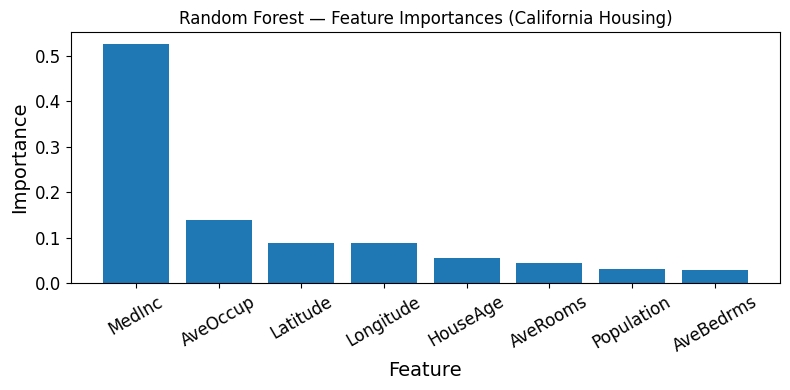

In [141]:
# -------------------------------------------------------
# TREE-BASED REGRESSION — SIDE-BY-SIDE COMPARISON
# Decision Tree: single tree, interpretable but overfits easily
# Random Forest: bagged trees, averages predictions → low variance
# Gradient Boosting: sequential trees on residuals → lowest error
# -------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models_reg = {
    'Decision Tree (depth=5)':    DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest (100 trees)':  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':          GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                            max_depth=3, random_state=42),
}

print(f'{"Model":<35} {"MSE":>8} {"R²":>8}')
print('-' * 55)
for name, model in models_reg.items():
    model.fit(X_tr_hs, y_tr_h)
    y_pred = model.predict(X_te_hs)
    mse = mean_squared_error(y_te_h, y_pred)
    r2  = r2_score(y_te_h, y_pred)
    print(f'{name:<35} {mse:>8.4f} {r2:>8.4f}')

# Feature importances from Random Forest
rf_reg = models_reg['Random Forest (100 trees)']
importances = rf_reg.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(range(len(importances)),
        importances[sorted_idx],
        tick_label=[housing.feature_names[i] for i in sorted_idx])
plt.xlabel('Feature'); plt.ylabel('Importance')
plt.title('Random Forest — Feature Importances (California Housing)')
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


## 8.6 SVR, KNN Regressor, and Bayesian Ridge

In [142]:
# -------------------------------------------------------
# SVR, KNN REGRESSOR, BAYESIAN RIDGE — COMPARISON
#
# SVR (Support Vector Regression):
#   Fits within an epsilon-tube; ignores errors < epsilon;
#   only penalises points outside the tube.
#
# KNN Regressor:
#   Predicts the average of K nearest neighbours' target values.
#   No training phase — all computation happens at prediction time.
#
# Bayesian Ridge:
#   Probabilistic version of Ridge; automatically estimates alpha (λ).
#   Returns UNCERTAINTY estimates alongside predictions.
# -------------------------------------------------------
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Use a smaller subset for SVR (it scales as O(n²) to O(n³))
X_tr_small = X_tr_hs[:2000]
y_tr_small = y_tr_h[:2000]

models_extra = {
    'SVR (RBF kernel)':   SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'KNN Regressor (k=10)': KNeighborsRegressor(n_neighbors=10, weights='distance'),
    'Bayesian Ridge':       BayesianRidge(),
}

print(f'{"Model":<25} {"MSE":>8} {"R²":>8}')
print('-' * 45)
for name, model in models_extra.items():
    model.fit(X_tr_small, y_tr_small)
    y_pred = model.predict(X_te_hs)
    print(f'{name:<25} {mean_squared_error(y_te_h, y_pred):>8.4f} {r2_score(y_te_h, y_pred):>8.4f}')

# Bayesian Ridge also gives UNCERTAINTY (std dev of prediction)
br = BayesianRidge()
br.fit(X_tr_hs, y_tr_h)
y_pred_br, y_std_br = br.predict(X_te_hs[:5], return_std=True)
print('\nBayesian Ridge — Predictions with Uncertainty (first 5 test samples):')
for pred, std, actual in zip(y_pred_br, y_std_br, y_te_h[:5]):
    print(f'  Predicted: {pred:.3f} ± {std:.3f}  |  Actual: {actual:.3f}')


Model                          MSE       R²
---------------------------------------------
SVR (RBF kernel)            0.4108   0.6865
KNN Regressor (k=10)        0.4984   0.6197
Bayesian Ridge              0.6212   0.5260

Bayesian Ridge — Predictions with Uncertainty (first 5 test samples):
  Predicted: 0.720 ± 0.720  |  Actual: 0.477
  Predicted: 1.764 ± 0.720  |  Actual: 0.458
  Predicted: 2.709 ± 0.720  |  Actual: 5.000
  Predicted: 2.839 ± 0.720  |  Actual: 2.186
  Predicted: 2.604 ± 0.720  |  Actual: 2.780


---
<a id='robust'></a>
# 📕 Robust Regression Algorithms

These algorithms are specifically designed to handle **outliers** in the data.
Standard OLS (Ordinary Least Squares) is highly sensitive to outliers; these methods are not.

| Algorithm | Mechanism | Outlier Tolerance |
|-----------|-----------|-------------------|
| Huber | Quadratic for small errors, linear for large | Moderate (~15%) |
| RANSAC | Random sampling of inliers, ignores outliers | High (>50%) |
| Theil-Sen | Median of all pairwise slopes | Up to 29.3% |
| Gaussian Process | Probabilistic; returns uncertainty | Not robust but gives uncertainty |


## 9.1 Huber Regression ⭐

**Theory:** Uses a **hybrid loss function**: quadratic (L2) for small errors, linear (L1) for large ones.
This makes it less sensitive to outliers than OLS, while remaining smooth and differentiable.

- `epsilon` controls the threshold where the loss switches from L2 to L1
  - `epsilon = 1.35` ≈ 95% efficiency vs OLS on clean Gaussian data
- Outliers in the **target variable** (y) are handled; feature outliers need other approaches

**Key Math:**
```
Huber loss:  L(r) = { (1/2)r²          if |r| ≤ δ
                    { δ|r| - (1/2)δ²   if |r| > δ
```


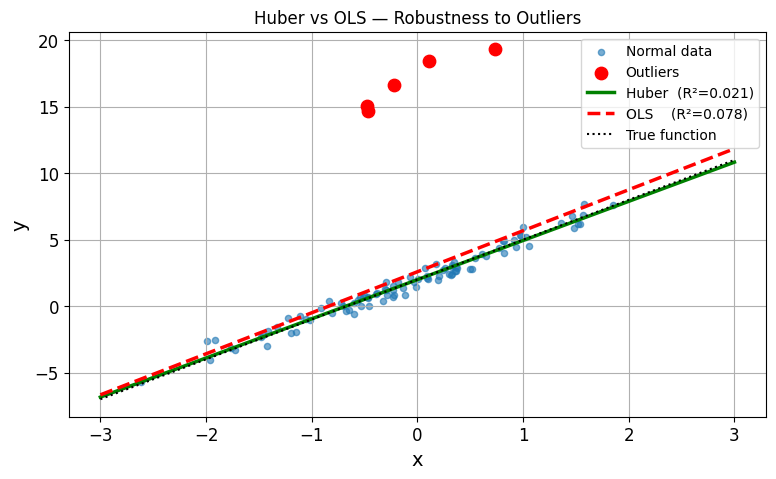

Huber stays close to the true line; OLS is pulled toward outliers.


In [143]:
# -------------------------------------------------------
# HUBER REGRESSION vs LINEAR REGRESSION
# Demonstrates how outliers pull OLS far off the true line
# while Huber stays close to the true relationship.
# -------------------------------------------------------
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100
X_hub = np.random.randn(n, 1)
y_hub = 3 * X_hub.squeeze() + 2 + np.random.randn(n) * 0.5  # true: y = 3x + 2

# Inject 5 extreme outliers
outlier_idx = [10, 25, 40, 60, 80]
y_hub[outlier_idx] += 15  # shift these points far away

X_tr_hub, X_te_hub, y_tr_hub, y_te_hub = train_test_split(
    X_hub, y_hub, test_size=0.2, random_state=42)

# Train both models
huber = HuberRegressor(epsilon=1.35)   # epsilon = transition point (1.35 is standard)
huber.fit(X_tr_hub, y_tr_hub)

lr_ols = LinearRegression()
lr_ols.fit(X_tr_hub, y_tr_hub)

X_plot_hub = np.linspace(-3, 3, 200).reshape(-1, 1)

plt.figure(figsize=(9, 5))
# Mark regular vs outlier points
is_outlier = np.isin(np.arange(len(X_hub)), outlier_idx)
plt.scatter(X_hub[~is_outlier], y_hub[~is_outlier], s=20, alpha=0.6, label='Normal data')
plt.scatter(X_hub[is_outlier],  y_hub[is_outlier],  s=80, color='red',
            zorder=5, label='Outliers')
plt.plot(X_plot_hub, huber.predict(X_plot_hub), 'g-', linewidth=2.5,
         label=f'Huber  (R²={r2_score(y_te_hub, huber.predict(X_te_hub)):.3f})')
plt.plot(X_plot_hub, lr_ols.predict(X_plot_hub), 'r--', linewidth=2.5,
         label=f'OLS    (R²={r2_score(y_te_hub, lr_ols.predict(X_te_hub)):.3f})')
plt.plot(X_plot_hub, 3*X_plot_hub + 2, 'k:', linewidth=1.5, label='True function')
plt.legend(); plt.grid(True)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Huber vs OLS — Robustness to Outliers')
plt.show()
print('Huber stays close to the true line; OLS is pulled toward outliers.')


## 9.2 RANSAC (RANdom SAmple Consensus) ⭐

**Theory:** Iteratively fits a model on small **random subsets** (inliers), then scores the model
by counting how many total points fall within a threshold. Returns the best model (most inliers).

- Works even with **>50% outliers** (where Huber/Theil-Sen struggle)
- Non-deterministic (random sampling) — set `random_state` for reproducibility
- `residual_threshold` controls what counts as an "inlier"

**Algorithm:**
```
For i = 1 to k iterations:
  1. Randomly pick n points (minimum needed to fit model)
  2. Fit model to these n points
  3. Count inliers: points where |y - ŷ| < threshold
  4. Keep best model (most inliers)
Return best model, refit on all its inliers
```


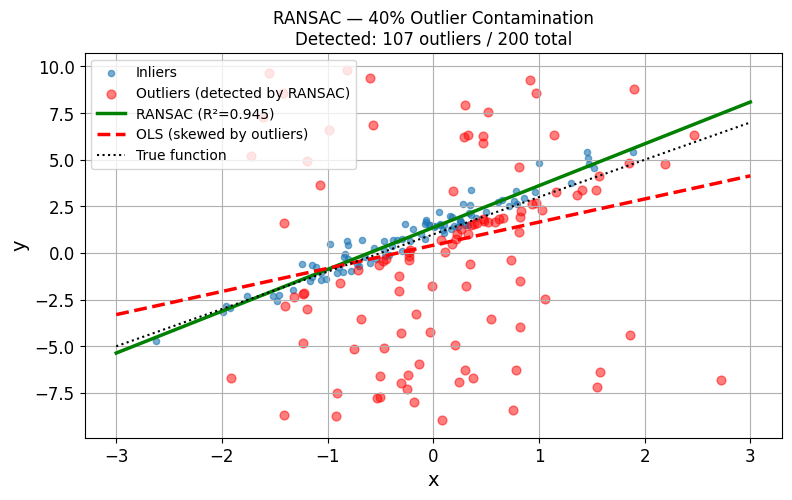

Inliers: 93 | Outliers detected: 107


In [144]:
# -------------------------------------------------------
# RANSAC REGRESSION
# min_samples: minimum points to fit model each iteration (default: auto)
# residual_threshold: max error to be considered an inlier
# max_trials: number of random iterations
# inlier_mask_: boolean array marking which training samples are inliers
# -------------------------------------------------------
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_ransac = 200
X_rans = np.random.randn(n_ransac, 1)
y_rans = 2 * X_rans.squeeze() + 1 + np.random.randn(n_ransac) * 0.5

# Add 40% outliers (very heavy contamination)
n_outliers = 80
out_idx = np.random.choice(n_ransac, n_outliers, replace=False)
y_rans[out_idx] = np.random.uniform(-10, 10, n_outliers)

# RANSAC: wraps a base estimator (LinearRegression by default)
ransac = RANSACRegressor(
    estimator=LinearRegression(), # Changed 'base_estimator' to 'estimator'
    residual_threshold=1.0,   # points within ±1.0 are inliers
    random_state=42
)
ransac.fit(X_rans, y_rans)

# Get inlier/outlier classification
inlier_mask  = ransac.inlier_mask_
outlier_mask = ~inlier_mask

X_plot_r = np.linspace(-3, 3, 200).reshape(-1, 1)
lr_base = LinearRegression().fit(X_rans.reshape(-1, 1), y_rans)

plt.figure(figsize=(9, 5))
plt.scatter(X_rans[inlier_mask],  y_rans[inlier_mask],  s=20, alpha=0.6, label='Inliers')
plt.scatter(X_rans[outlier_mask], y_rans[outlier_mask], s=40, color='red',
            alpha=0.5, label='Outliers (detected by RANSAC)')
plt.plot(X_plot_r, ransac.predict(X_plot_r), 'g-', linewidth=2.5,
         label=f'RANSAC (R²={ransac.score(X_rans[inlier_mask], y_rans[inlier_mask]):.3f})')
plt.plot(X_plot_r, lr_base.predict(X_plot_r), 'r--', linewidth=2.5,
         label='OLS (skewed by outliers)')
plt.plot(X_plot_r, 2*X_plot_r + 1, 'k:', linewidth=1.5, label='True function')
plt.legend(); plt.grid(True)
plt.xlabel('x'); plt.ylabel('y')
plt.title(f'RANSAC — 40% Outlier Contamination\nDetected: {outlier_mask.sum()} outliers / {n_ransac} total')
plt.show()
print(f'Inliers: {inlier_mask.sum()} | Outliers detected: {outlier_mask.sum()}')

## 9.3 Theil-Sen Regression

**Theory:** Computes the **median slope** from all possible pairs of points. Uses the median intercept.
Since it uses the median (not mean), it is highly resistant to outliers.

- **Breakdown point ≈ 29.3%** — can tolerate up to 29.3% outliers
- Computationally expensive: O(n²) pairs — avoid on datasets with n > 10,000
- More deterministic than RANSAC (no randomness)

**Key Math:**
```
For all pairs (i, j): slope mᵢⱼ = (yⱼ - yᵢ) / (xⱼ - xᵢ)
β (slope)     = median{mᵢⱼ}
b (intercept) = median{yᵢ - β·xᵢ}
```


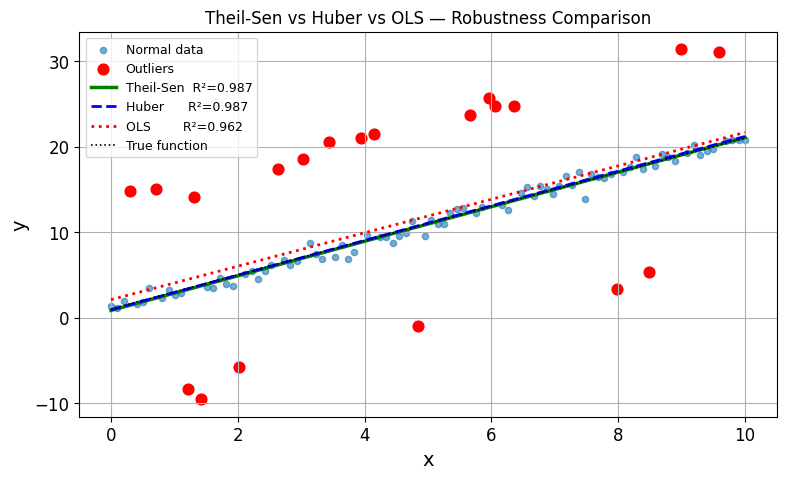

In [145]:
# -------------------------------------------------------
# THEIL-SEN REGRESSION
# No key hyperparameters to tune — it's a purely median-based method.
# max_subpopulation limits pairs considered (for speed on large datasets).
# -------------------------------------------------------
from sklearn.linear_model import TheilSenRegressor
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_ts = 100
X_ts = np.linspace(0, 10, n_ts).reshape(-1, 1)
y_ts = 2 * X_ts.squeeze() + 1 + np.random.randn(n_ts) * 0.8

# Add ~20% outliers (within the 29.3% breakdown point)
outlier_ts = np.random.choice(n_ts, 20, replace=False)
y_ts[outlier_ts] += np.random.choice([-12, 12], size=20)

# Fit all three robust methods for comparison
theilsen  = TheilSenRegressor(random_state=42)
huber_ts  = HuberRegressor(epsilon=1.35)
ols_ts    = LinearRegression()

for model in [theilsen, huber_ts, ols_ts]:
    model.fit(X_ts, y_ts)

X_plot_ts = np.linspace(0, 10, 300).reshape(-1, 1)
plt.figure(figsize=(9, 5))
mask_ts = ~np.isin(np.arange(n_ts), outlier_ts)
plt.scatter(X_ts[mask_ts],  y_ts[mask_ts],  s=20, alpha=0.6, label='Normal data')
plt.scatter(X_ts[~mask_ts], y_ts[~mask_ts], s=60, color='red', label='Outliers')
plt.plot(X_plot_ts, theilsen.predict(X_plot_ts), 'g-',  lw=2.5,
         label=f'Theil-Sen  R²={r2_score(y_ts[mask_ts], theilsen.predict(X_ts[mask_ts])):.3f}')
plt.plot(X_plot_ts, huber_ts.predict(X_plot_ts), 'b--', lw=2,
         label=f'Huber      R²={r2_score(y_ts[mask_ts], huber_ts.predict(X_ts[mask_ts])):.3f}')
plt.plot(X_plot_ts, ols_ts.predict(X_plot_ts),   'r:',  lw=2,
         label=f'OLS        R²={r2_score(y_ts[mask_ts], ols_ts.predict(X_ts[mask_ts])):.3f}')
plt.plot(X_plot_ts, 2*X_plot_ts + 1, 'k:', lw=1.2, label='True function')
plt.legend(fontsize=9); plt.grid(True)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Theil-Sen vs Huber vs OLS — Robustness Comparison')
plt.show()


## 9.4 Gaussian Process Regression (GPR)

**Theory:** A non-parametric, **fully probabilistic** model that defines a distribution over functions.
Unlike other regressors that return a single value, GPR returns a **mean prediction + uncertainty (std dev)**.

- **Kernel function** defines how similar two points are (RBF = nearby points are similar)
- Uncertainty is **low** near training data, **high** in regions with no data
- Scales as **O(n³)** — only practical for small datasets (< ~5000 samples)
- Critical for **active learning**, **Bayesian optimisation**, and **robotics**

**Key Math:**
```
Prior:    f(x) ~ GP(0, k(x, x'))      ← kernel defines correlation structure
Posterior: μ*(x*) = K*ᵀ(K + σ²I)⁻¹y   ← mean prediction
           Σ*(x*) = K** - K*ᵀ(K + σ²I)⁻¹K*  ← variance (uncertainty)
Common kernel: RBF  k(x,x') = σ²exp(-||x-x'||²/(2l²))
```


Optimised kernel: 0.592**2 * RBF(length_scale=0.841)
R² on training data: 0.9756


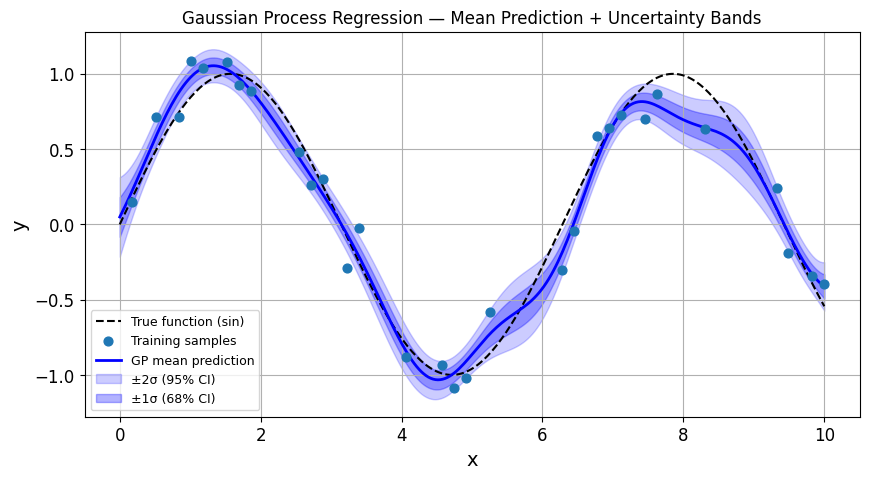

Wide bands = high uncertainty (far from training data)
Narrow bands = confident prediction (near training data)


In [146]:
# -------------------------------------------------------
# GAUSSIAN PROCESS REGRESSION
# kernel: defines the covariance structure between points
#   ConstantKernel * RBF is a common choice
#   RBF length_scale controls how quickly correlation falls off with distance
# return_std=True returns the standard deviation (uncertainty) per prediction
# alpha: noise level added to the diagonal of the kernel matrix (numerical stability)
# -------------------------------------------------------
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create 1-D sinusoidal data
X_gp = np.linspace(0, 10, 60).reshape(-1, 1)
y_gp = np.sin(X_gp).ravel() + np.random.randn(60) * 0.15

# Use only 30 points for training — GPR works well with small data
idx = np.random.choice(60, 30, replace=False)
X_tr_gp, y_tr_gp = X_gp[idx], y_gp[idx]

# Define kernel: amplitude × RBF (length_scale = how wide the influence of each point is)
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,         # small noise term for numerical stability
    n_restarts_optimizer=5,  # restart optimiser multiple times to find best kernel params
    random_state=42
)
gp.fit(X_tr_gp, y_tr_gp)

# Predict on a dense grid — also get uncertainty (standard deviation)
X_pred_gp = np.linspace(0, 10, 300).reshape(-1, 1)
y_mean, y_std = gp.predict(X_pred_gp, return_std=True)  # mean + std

print(f'Optimised kernel: {gp.kernel_}')
print(f'R² on training data: {r2_score(y_tr_gp, gp.predict(X_tr_gp)):.4f}')

plt.figure(figsize=(10, 5))
plt.plot(X_pred_gp, np.sin(X_pred_gp), 'k--', lw=1.5, label='True function (sin)')
plt.scatter(X_tr_gp, y_tr_gp, s=40, zorder=5, label='Training samples')
plt.plot(X_pred_gp, y_mean, 'b-', lw=2, label='GP mean prediction')

# Shade the ±2 std confidence interval (≈95%)
plt.fill_between(X_pred_gp.ravel(),
                 y_mean - 2*y_std, y_mean + 2*y_std,
                 alpha=0.2, color='blue', label='±2σ (95% CI)')
plt.fill_between(X_pred_gp.ravel(),
                 y_mean - y_std, y_mean + y_std,
                 alpha=0.3, color='blue', label='±1σ (68% CI)')

plt.xlabel('x'); plt.ylabel('y')
plt.title('Gaussian Process Regression — Mean Prediction + Uncertainty Bands')
plt.legend(fontsize=9); plt.grid(True)
plt.show()
print('Wide bands = high uncertainty (far from training data)')
print('Narrow bands = confident prediction (near training data)')


---
<a id='projects-ref'></a>
# 🚀 Real-World Projects

Quick end-to-end examples showing algorithms applied to realistic scenarios.


### 10.1 Email Spam Detection (Naive Bayes)

In [147]:
# -------------------------------------------------------
# SPAM DETECTION — END-TO-END PIPELINE
# Real spam classifiers use CountVectorizer or TF-IDF to turn
# email text into feature vectors, then Naive Bayes to classify.
# -------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# More realistic sample data
train_emails = [
    'Get rich quick! Buy now! Free cash!',
    'Meeting at 3pm tomorrow in room 4B',
    'Win a free iPhone now click here',
    'Quarterly budget report Q4 attached',
    'URGENT claim your prize you are winner',
    'Team lunch on Friday cafeteria',
    'Congratulations you won lottery money transfer',
    'Project deadline is next Monday reminder',
    'Limited offer discount 90 percent buy now',
    'Please review pull request on GitHub',
]
train_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

test_emails = [
    'Free money click here now win prize',  # should be spam
    'Budget meeting next Tuesday at noon',   # should be ham
]

# Pipeline: TF-IDF vectorisation → Multinomial Naive Bayes
# TF-IDF weighs words by how unique they are to the document (better than raw counts)
spam_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),  # unigrams + bigrams
    ('clf',   MultinomialNB(alpha=0.5))
])
spam_pipeline.fit(train_emails, train_labels)

preds = spam_pipeline.predict(test_emails)
probs = spam_pipeline.predict_proba(test_emails)

print('Spam Detection Results:')
for email, pred, prob in zip(test_emails, preds, probs):
    label = '🔴 SPAM' if pred == 1 else '🟢 HAM '
    print(f'  {label} ({prob[1]:.0%} spam) | "{email[:45]}"')


Spam Detection Results:
  🔴 SPAM (81% spam) | "Free money click here now win prize"
  🟢 HAM  (28% spam) | "Budget meeting next Tuesday at noon"


## 10.2 Algorithm Comparison Dashboard

Algorithm                       R²      MSE  Time(s)
-------------------------------------------------------
Linear Regression           0.5758   0.5559    0.005
Ridge (alpha=1)             0.5758   0.5559    0.007
Lasso (alpha=0.01)          0.5816   0.5483    0.021
Elastic Net                 0.5803   0.5500    0.023
Bayesian Ridge              0.5758   0.5558    0.005
Huber Regression            0.5610   0.5752    0.186
Decision Tree (d=5)         0.5997   0.5245    0.157
Random Forest               0.8053   0.2552   12.814
Gradient Boosting           0.7756   0.2940    4.694
KNN (k=10)                  0.6823   0.4163    0.017
SVR (2000 samples)          0.6865   0.4108    0.147


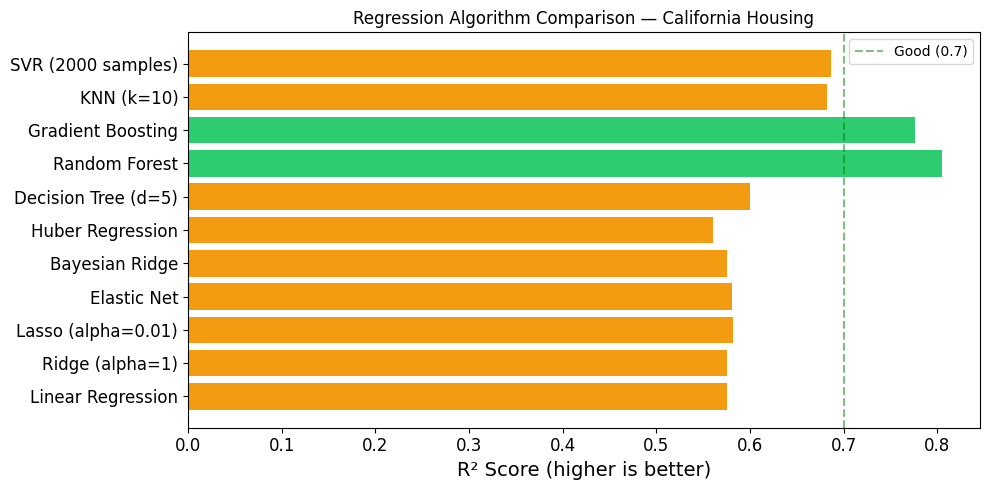

In [148]:
# -------------------------------------------------------
# ALGORITHM COMPARISON ON CALIFORNIA HOUSING
# Quick benchmark of ALL regression algorithms on the same dataset.
# This is a good pattern to follow when starting a new ML project:
# train many models quickly, then tune the top performers.
# -------------------------------------------------------
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    HuberRegressor, BayesianRidge
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import time

# Use scaled data from earlier (X_tr_hs, X_te_hs, y_tr_h, y_te_h)

benchmark_models = {
    'Linear Regression':     LinearRegression(),
    'Ridge (alpha=1)':       Ridge(alpha=1.0),
    'Lasso (alpha=0.01)':    Lasso(alpha=0.01, max_iter=10000),
    'Elastic Net':           ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    'Bayesian Ridge':        BayesianRidge(),
    'Huber Regression':      HuberRegressor(epsilon=1.35, max_iter=500),
    'Decision Tree (d=5)':   DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN (k=10)':            KNeighborsRegressor(n_neighbors=10, weights='distance'),
    'SVR (2000 samples)':    SVR(kernel='rbf', C=1.0),
}

results = {}
print(f'{"Algorithm":<25} {"R²":>8} {"MSE":>8} {"Time(s)":>8}')
print('-' * 55)

for name, model in benchmark_models.items():
    X_tr_use = X_tr_hs[:2000] if 'SVR' in name else X_tr_hs
    y_tr_use = y_tr_h[:2000]  if 'SVR' in name else y_tr_h
    t0 = time.time()
    model.fit(X_tr_use, y_tr_use)
    elapsed = time.time() - t0
    y_pred = model.predict(X_te_hs)
    r2  = r2_score(y_te_h, y_pred)
    mse = mean_squared_error(y_te_h, y_pred)
    results[name] = r2
    print(f'{name:<25} {r2:>8.4f} {mse:>8.4f} {elapsed:>8.3f}')

# Visualise R² comparison
plt.figure(figsize=(10, 5))
bars = plt.barh(list(results.keys()), list(results.values()),
                color=['#2ecc71' if v > 0.7 else '#e74c3c' if v < 0.4 else '#f39c12'
                       for v in results.values()])
plt.xlabel('R² Score (higher is better)')
plt.title('Regression Algorithm Comparison — California Housing')
plt.axvline(0.7, color='green', linestyle='--', alpha=0.5, label='Good (0.7)')
plt.legend()
plt.tight_layout()
plt.show()
